# A Poisson Count Race as a Generative Bridge Between Logit and Probit

Choice

Vencislav Popov [ORCID profile for Vencislav Popov](https://orcid.org/0000-0002-8073-4199) (Department of Psychology, University of Zurich)

This study embeds the two canonical discrete choice specifications - multinomial logit and multinomial probit - in a single generative family built on a count process. The model is a Poisson count race: $K$ alternatives generate events via independent Poisson processes, and a choice occurs when one alternative reaches a cumulative count threshold $\theta$. At the single-event threshold, $\theta=1$, the model yields the Multinomial Logit (Luce choice rule). Normalizing the utility noise to constant variance, I show that as $\theta \to \infty$ the model converges to the independent Multinomial Probit. The distributional ingredients are classical - the induced errors form the log-Gamma family of survival analysis, and Poisson races of static choice have a psychometric history. The contribution is the synthesis: a variance-standardized formulation in which logit and probit occupy the endpoints of one generative family, with $\theta$ governing noise shape, a separate parameter $\beta$ its scale, and systematic utilities $v_i$ shared across regimes. Two extensions generate correlated probit models. Shared evidence streams induce positive dependence and imply an upper bound coupling attainable correlations to utility differences and thresholds. Reciprocal inhibition - signed evidence streams that favor some alternatives while suppressing others - recovers, in a high-threshold first-passage limit, every choice-relevant probit covariance, at the cost of the count-process representation. The unification is distributional rather than dynamical: changes in $\theta$ compare accumulation regimes at matched discriminability, not a single system adjusting its threshold.

In [ ]:
source("R/race_functions.R")
source("R/model_illustrations.R")

library(ggplot2)
library(ggdist)
library(distributional)
library(patchwork)
library(actuar)


Attaching package: 'actuar'

The following objects are masked from 'package:stats':

    sd, var

The following object is masked from 'package:grDevices':

    cm

Discrete choice models based on Random Utility (RU) theory ([McFadden, 1974](#ref-mcfaddenConditionalLogitAnalysis1974)) form a central pillar of mathematical psychology, econometrics, and cognitive science. In these models, each alternative in a choice set elicits a *latent* scalar quantity - often interpreted as strength, utility, or evidence - and the observed choices arise from a comparison of these latent quantities under stochastic variability. The general setup is surprisingly simple. Consider a decision-maker facing a set of $K \ge 2$ mutually exclusive alternatives. The utility associated with alternative $i$ can be decomposed into a systematic component, $v_i$, and a stochastic component, $\epsilon_i$:

$$
U_{i} = v_{i} + \epsilon_{i}, \quad i=1, \dots, K
$$

The decision-maker then selects the alternative with maximum utility:

$$
C = \arg \max_{i \in K} U_{i}
$$

While the term “utility” implies an economic setting, the underlying mathematical model concerns any situation in which choices are probabilistic. The core concept is that of a shared *random scale* on which multiple latent variables, each associated with a different choice, are represented. Any choice model that implements this assumption, together with the max choice rule, is said to have a random-scale representation or to be random-scale representible ([Falmagne, 1978](#ref-falmagneRepresentationTheoremFinite1978a); [Kellen et al., 2021](#ref-kellenTestingFoundationsSignal2021)).

Within this general framework, different assumptions about the distribution of errors, $\epsilon_i$, determine the structure of the choice model and its predictions. Two important classes dominate the field: logit-based models, derived from Luce’s choice axiom and extreme-value theory ([Luce, 1959](#ref-luceIndividualChoiceBehavior1959); [McFadden, 1974](#ref-mcfaddenConditionalLogitAnalysis1974); [Yellott, 1977](#ref-yellottRelationshipLucesChoice1977)), and probit-based models, derived from Thurstone’s Theory of comparative judgements and gaussian Signal Detection Theory ([Hausman & Wise, 1978](#ref-hausmanConditionalProbitModel1978a); [Robinson et al., 2023](#ref-robinsonHowPeopleBuild2023); [Thurstone, 1927](#ref-thurstoneLawComparativeJudgment1927); [Wixted, 2020](#ref-wixtedForgottenHistorySignal2020)). These two model families correspond to two types of error distributions:

1.  **Gumbel Errors:** If the $\epsilon_i$ terms are independent and identically distributed (i.i.d.) according to a Type I Extreme Value distribution, the choice probabilities follow the **Multinomial Logit (MNL)** or Softmax form.

2.  **Gaussian Errors:** If the $\epsilon_i$ terms follow a Multivariate Normal distribution (potentially allowing for correlated errors across alternatives) the choice probabilities are described by the **Multinomial Probit (MNP)** model.

In [ ]:
utilities <- seq(0, 2, length.out = 8)
norm_util <- plot_utility_distributions(utilities,
  dist_fun = dist_normal,
  title = "Gaussian (Normal) noise",
  sd = 1
)
gumbel_util <- plot_utility_distributions(utilities,
  dist_fun = dist_gumbel,
  title = "Gumbel (Type I EV) noise",
  scale = sqrt(6) / pi
)

softmax_eq <- plot_softmax_equation()
probit_eq  <- plot_probit_equation()

(gumbel_util | softmax_eq) / (norm_util | probit_eq)

The random utility framework thus unifies axiomatic choice models ([Luce, 1959](#ref-luceIndividualChoiceBehavior1959)) and measurement detection-based models ([Thurstone, 1927](#ref-thurstoneLawComparativeJudgment1927)) under a single functional form. However, the unification currently stops there - the different error distributions reflect different assumptions about the generating process. As Robinson et al. ([2023](#ref-robinsonHowPeopleBuild2023)) recently put it, the two models “describe different ways of translating sensory evidence into decision variables.”.

The central question addressed in this paper is this: Can the two canonical random-utility discrete-choice specifications — multinomial logit and multinomial probit — be derived from a shared generative mechanism? Can we find a deeper unifying principle? The answer developed here is yes - both models can be derived as limit cases of a single stochastic evidence accumulation mechanism. Little of the machinery required is new: the pieces are classical results from statistics and from race models of choice, reviewed below. The contribution lies in assembling them into an explicit bridge, in which the key distinction between the two models is not the form of the utility noise itself, but the stopping rule governing how stochastic evidence is accumulated before a choice is made.

## Model overview

Take a **Poisson count race** ([Pike, 1973](#ref-pikeResponseLatencyModels1973); [Smith & Van Zandt, 2000](#ref-smithTimedependentPoissonCounter2000a); [Townsend & Ashby, 1983](#ref-townsendStochasticModelingElementary1983)), wherein each alternative generates stochastic events via an independent Poisson process. A decision is made when one alternative reaches a cumulative count threshold $\theta$. The threshold $\theta$ thus controls how much stochastic evidence must be accumulated before commitment.

Without any additional modifications, such a model predicts increasingly deterministic responses, and in the limit as $\theta \to \infty$ it leads to choosing the option with the highest utility 100% of the time. To prevent this, and to compare noise *shape* across $\theta$ independently of noise *scale*, we must standardize the stochastic utility component to unit variance for all $\theta$, with a separate parameter $\beta$ controlling the overall magnitude of stochasticity. With this normalization, we can establish three main results:

1.  At $\theta = 1$, this reduces exactly to the Multinomial Logit
2.  For any $\theta \ge 1$, the Poisson count race is isomorphic to a random utility model with log-Gamma noise, interpolating between Gumbel and Gaussian error distributions;
3.  As $\theta \to \infty$ the model converges to the Multinomial Probit.

From this perspective, logit and probit can be understood as members of a single parametric family of evidence accumulation models that differ in the accumulation stopping rule. Extreme-value noise and Gaussian noise arise as the two endpoint regimes of log-Gamma noise, which is the natural error distribution of Poisson count races. It is important to note, however, that this unification is algebraic and distributional rather than dynamical: the standardization that enables comparison across $\theta$ values compares different accumulation systems at matched discriminability, not a single system under threshold variation (see <a href="#sec-variance-normalization" class="quarto-xref">Section 3</a> for details).

Beyond the independent family, two further constructions extend the Gaussian endpoint to correlated choice. Shared evidence streams generate a structured class of positively correlated probit models, while signed evidence streams — reciprocal inhibition — recover, in the high-threshold limit, every choice-relevant covariance structure of the correlated Multinomial Probit (<a href="#sec-correlated-errors" class="quarto-xref">Section 7</a>, <a href="#sec-inhibitory-race" class="quarto-xref">Section 8</a>).

## Relation to prior work

Both main ingredients of this construction have substantial histories. On the process side, Poisson counter models are a classical tool of mathematical psychology, developed primarily as accounts of response time distributions ([Pike, 1973](#ref-pikeResponseLatencyModels1973); [Smith & Van Zandt, 2000](#ref-smithTimedependentPoissonCounter2000a); [Townsend & Ashby, 1983](#ref-townsendStochasticModelingElementary1983)). Race mechanisms are also known to induce random utility representations for static choice: Marley & Colonius ([1992](#ref-marleyHorseRaceRandom1992)) analyzed the general “horse race” random utility model, in which independent random completion times play exactly the role that the waiting times play here. Most directly, Poisson races have been developed as process-based random-utility accounts of *static* conjoint choice. Otter et al. ([2008](#ref-otterIntegratedModelDiscrete2008)) built an integrated model of choice and response time on a thresholded Poisson race, noting that it recovers the multinomial logit exactly at threshold one, departs from IIA in a structured way at higher thresholds, and yields a probit if the race is instead stopped at a fixed exogenous time; Ruan et al. ([2008](#ref-ruanDependentPoissonRace2008a)) developed the dependent Poisson race, derived its choice probabilities, and showed that it outperforms the multinomial logit empirically; because that model induces dependence through shared event streams, the covariance structures it can realize are confined to the non-negative, common-shock class. Poisson races as generators of static choice models are therefore not new in themselves.

On the distributional side, the error family induced by the race is equally classical. The negative logarithm of a Gamma variate follows a log-gamma distribution ([Consul & Jain, 1971](#ref-consulLoggammaDistributionIts1971a)), and Prentice ([1974](#ref-prenticeLogGammaModel1974)) developed precisely this family — rooted in the generalized gamma distribution of Stacy ([1962](#ref-stacyGeneralizationGamma1962)) — as a parametric interpolation in which the extreme value distributions are included as special cases and the normal arises as the central limiting case of the shape parameter. That family, and the normal limit of the standardized log-gamma, are standard tools in survival analysis ([Lawless, 1980](#ref-lawlessInferenceGeneralizedGamma1980)). In the binary case, even the choice-probability consequence is anticipated: Stern ([1990](#ref-sternContinuumPairedComparisons1990)) constructed a continuum of paired comparison models from races between Gamma variates, recovering the Bradley–Terry (logit) model at shape one and the Thurstone–Mosteller (probit) model in the limit of large shape.

The contribution of the present paper is the synthesis of these threads into an explicit generative bridge between the two canonical multinomial choice models, together with the following results that, to my knowledge, are new:

1.  **The multinomial probit endpoint under matched discriminability.** Under an explicit variance standardization, the $\theta = 1$ member of the family is exactly the Multinomial Logit and the $\theta \to \infty$ limit is exactly the independent Multinomial Probit, for any number of alternatives (<a href="#sec-probit-limit" class="quarto-xref">Section 4</a>). Logit and probit are thereby characterized as the two *endpoints* of a single generative family. Prior work treated the Poisson race as an empirical alternative to the logit ([Otter et al., 2008](#ref-otterIntegratedModelDiscrete2008); [Ruan et al., 2008](#ref-ruanDependentPoissonRace2008a)), not as a bridge to the probit: Otter et al. ([2008](#ref-otterIntegratedModelDiscrete2008)) obtained a probit only by switching to a different stopping rule (a fixed exogenous deadline), whereas here the independent probit is reached within the threshold-stopping family itself, as its variance-standardized $\theta \to \infty$ limit.

2.  **A precise statement of what the bridge does and does not claim.** The unification is distributional rather than dynamical: the standardization compares different accumulation systems at matched discriminability, and a single system cannot move from logit to probit behavior merely by raising its threshold (<a href="#sec-variance-normalization" class="quarto-xref">Section 3</a>).

3.  **A generative construction for positively correlated probit models, and the constraint it carries.** Extending the race with shared feature generators induces positive dependence among the accumulators and yields, in the large-threshold limit, a correlated Multinomial Probit whose covariance structure is inherited from those shared generators. This construction spans only covariances realizable by non-negative shared Poisson rates, and within that class it implies a strict upper bound, $\rho_{\max} = \exp(-(v_1 - v_2)\sigma_\theta/2)$ (where $\sigma_\theta$ is the scale of the unstandardized log-Gamma noise), on the correlation attainable between two alternatives of unequal utility at a given threshold (<a href="#sec-correlated-errors" class="quarto-xref">Section 7</a>).

4.  **A representation theorem for the correlated Multinomial Probit.** A second construction, based on reciprocal inhibition — signed evidence streams that favor some alternatives while counting against others — recovers in the high-threshold limit *every* choice-relevant probit covariance, including negative dependence (Result 5, <a href="#sec-inhibitory-race" class="quarto-xref">Section 8</a>). Whereas existing dependent-race models ([Ruan et al., 2008](#ref-ruanDependentPoissonRace2008a)) generate dependence only through common shocks, and are thereby confined to a restricted class of non-negative covariances, the signed construction spans the full choice-relevant class. The generality comes at the cost of the count-process representation, and the mechanism still carries a finite-threshold bound, analogous to $\rho_{\max}$, coupling expressible utility contrasts to available noise.

5.  **A process-level account of parameter invariance across set size.** The framework explains why probit (signal detection) parameters remain stable across the number of alternatives while softmax parameters drift — the pattern documented empirically by Robinson et al. ([2023](#ref-robinsonHowPeopleBuild2023)) (Study 5 in <a href="#sec-multinomial-simulations" class="quarto-xref">Section 6</a>).

The remainder of the paper formalizes this framework, presents simulations illustrating the interpolation between regimes, and discusses implications for discrete choice modeling.

# 1. The Generative Model: A Poisson Count Race

Let the accumulation of evidence or preference for each alternative $i$ be modeled by independent Poisson count processes, denoted $N_i(t)$, with rate parameters $\lambda_i > 0$. Here $N_i(t)$ represents cumulative count for alternative $i$ at time $t$.

Then, define a **count race** characterized by an integer threshold $\theta \ge 1$. The process terminates as soon as any single alternative accumulates $\theta$ events.

**Definition 1 (Stopping Time).** The stopping time for the system is the first time any process hits the threshold:

$$
\tau_{\theta} = \inf \{t \ge 0 : \max_{i} N_i(t) = \theta \}
$$

**Definition 2 (Choice).** The chosen alternative is the specific process that triggers the stopping time:

$$
C = \arg \max_{i} N_i(\tau_{\theta})
$$

## 1.1 Transformation to Waiting Times

To map this stochastic process to a random utility framework, consider $T_i^{(\theta)}$, the waiting time until the $i$-th process records its $\theta$-th event:

$$
T_i^{(\theta)} := \inf \{t : N_i(t) = \theta \}
$$

For a Poisson process with rate $\lambda_i$, the waiting time to the $\theta$-th jump follows a Gamma (Erlang) distribution with shape $\theta$ and rate $\lambda_i$:

$$
T_i^{(\theta)} \sim \text{Gamma}(\text{shape}=\theta, \text{rate}=\lambda_i)
$$

The condition that alternative $i$ wins the race is equivalent to observing the minimum waiting time:

$$
C = \arg \min_{i} T_i^{(\theta)}
$$

## 1.2 The Random Utility Representation

Since the Poisson processes are independent, the waiting times $T_1^{(\theta)}, \ldots, T_K^{(\theta)}$ are mutually independent. Utilizing the scaling property of the Gamma distribution, we can express each waiting time as:

$$
T_i^{(\theta)} \stackrel{d}{=} \frac{G_i}{\lambda_i}
$$

where $G_1, \ldots, G_K \stackrel{\text{i.i.d.}}{\sim} \text{Gamma}(\theta, 1)$ are standard Gamma random variables. The choice problem then becomes:

$$
C = \arg \min_{i} \left( \frac{G_i}{\lambda_i} \right)
$$

Applying the natural logarithm and taking the negative, a monotonic transformation, reverses the optimization direction from minimization to maximization:

$$
\begin{aligned} C &= \arg \min_{i} (\log G_i - \log \lambda_i) \\ &= \arg \max_{i} (\log \lambda_i - \log G_i) \end{aligned}
$$

This establishes an exact Random Utility Model (RUM) structure:

$$
U_i^{(\theta)} = v_i + \epsilon_i^{(\theta)}
$$

where:

- **Systematic Utility:** $v_i = \log \lambda_i$  
- **Stochastic Error:** $\epsilon_i^{(\theta)} = -\log G_i$, with $G_i \sim \text{Gamma}(\theta, 1)$.

Thus, the Poisson count race is isomorphic to a Random Utility Model characterized by Log-Gamma noise.

> **Result 1 (Log-Gamma Random Utility Family)**
>
> For any integer threshold $\theta \ge 1$, the Poisson count race induces a random utility model $U_i^{(\theta)} = \log \lambda_i - \log G_i$ with i.i.d. log-Gamma($\theta$) noise.

Result 1 involves no new distribution theory: $-\log G_i$ follows the log-gamma distribution reviewed in the introduction, whose shape parameter interpolates between extreme-value and normal shapes ([Consul & Jain, 1971](#ref-consulLoggammaDistributionIts1971a); [Lawless, 1980](#ref-lawlessInferenceGeneralizedGamma1980); [Prentice, 1974](#ref-prenticeLogGammaModel1974)). What the Poisson race adds is an interpretation. Embedded in a race with a count threshold, the shape parameter of this classical family acquires a process meaning — the amount of evidence required before commitment — and the distributional family becomes a family of random utility models.

# 2. The Logit Boundary ($\theta = 1$)

In the specific instance where the threshold is a single event ($\theta = 1$), the waiting time distribution simplifies to the Exponential distribution:

$$
G_i \sim \text{Gamma}(1, 1) \equiv \text{Exponential}(1)
$$

A fundamental property of Extreme Value Theory is the relationship between the Exponential and Gumbel distributions:

$$
X \sim \text{Exp}(1) \implies -\log(X) \sim \text{Gumbel}(\text{Type I EV})
$$

Therefore, when $\theta=1$, the noise terms $\epsilon_i^{(1)}$ are i.i.d. standard Gumbel. This recovers the exact Multinomial Logit formula:

$$
\Pr(C=i) = \frac{\exp(v_i)}{\sum_{j=1}^K \exp(v_j)} = \frac{\lambda_i}{\sum_{j=1}^K \lambda_j}
$$

> **Result 2 (Logit Boundary)**
>
> The Poisson count race with threshold $\theta=1$ recovers the Multinomial Logit model exactly, with deterministic utility components equal to the log rate of their poisson counterparts. The accumulation of a single unit of evidence corresponds to the Luce Choice Rule (Softmax). This is a classic, well-known derivation.

# 3. Variance normalization

For thresholds $\theta > 1$, the error distribution deviates from the Gumbel form. More critically, as $\theta$ increases, the variance of the error term diminishes. Specifically, for $\epsilon^{(\theta)} = -\log G$ where $G \sim \text{Gamma}(\theta, 1)$, the moments are:

$$
\begin{aligned} \mathbb{E}[\epsilon^{(\theta)}] &= -\psi(\theta) \\ \text{Var}(\epsilon^{(\theta)}) &= \psi_1(\theta) \end{aligned}
$$

where $\psi(\cdot)$ is the digamma function and $\psi_1(\cdot)$ is the trigamma function.

As $\theta \to \infty$, the variance $\psi_1(\theta) \approx 1/\theta \to 0$. Without intervention, the model would converge to a deterministic choice rule (argmax of systematic utilities) simply because the noise vanishes. To facilitate a meaningful comparison of error shapes across varying $\theta$, we must enforce a consistent scale.

Define the standardized noise term $Z_i^{(\theta)}$ to have zero mean and unit variance for all $\theta$:

$$
Z_i^{(\theta)} := \frac{\epsilon_i^{(\theta)} - \mu_\theta}{\sigma_\theta} = \frac{-\log G_i + \psi(\theta)}{\sqrt{\psi_1(\theta)}}
$$

This leads to family of utility models with matched discriminability:

$$
U_i^{(\theta)} = v_i + \beta Z_i^{(\theta)}
$$

Here:

- $v_i$ is the systematic utility (evidence rate).
- $\theta$ governs the shape of the noise (from skewed Gumbel to symmetric Gaussian).
- $\beta$ governs the temperature (the magnitude of noise relative to utility).

An important caveat accompanies this construction. In a random utility model, rescaling all utilities by a common positive constant does not change choice probabilities. If we multiply both terms by $\sigma_\theta = \sqrt{\psi_1(\theta)}$, we would not change the predicted probabilities. Therefore, the variance-normalized model $U_i^{(\theta)} = v_i + \beta Z_i^{(\theta)}$ is observationally equivalent to a model with systematic utilities $v_i \sigma_\theta$ and *unstandardized* log-Gamma noise $\epsilon_i^{(\theta)}$.

This has an important theoretical consequence: the standardized distributions cannot describe the behavior of a single accumulation system under threshold variation. For a fixed set of Poisson rates $\lambda_i$, increasing $\theta$ both reshapes the noise and reduces its variance; the variance reduction alone drives choice toward determinism regardless of shape. The standardization removes this confound by comparing across systems with different effective rate structures — specifically, the effective rates would need to scale as $\lambda_i^{\sigma_\theta}$ to maintain constant discriminability. However, it is not psychologically plausible that a decision-maker can affect the utilities / poisson rates in exactly the right way if they choose a higher, more conservative threshold. Simply put - a single decision-making system cannot wait its way from a logit to a probit model while keeping discriminability fixed.

The unification established here is therefore *distributional* — logit and probit belong to the same parametric family of log-Gamma random utility models — rather than *dynamical*. One cannot convert a logit-like decision process into a probit-like one merely by raising the decision threshold within a single system. Rather, different regimes likely describe the functioning of different decision-making systems.

# 4. The Probit Limit ($\theta \to \infty$)

This section establishes the asymptotic behavior of the variance-standardized model.

Recall that $G_i \sim \text{Gamma}(\theta, 1)$. For integer $\theta$, $G_i$ can be represented as the sum of $\theta$ independent exponential variables: $G_i = \sum_{j=1}^{\theta} E_{ij}$. By the Central Limit Theorem, the standardized variable converges to a standard normal distribution:

$$
\frac{G_i - \theta}{\sqrt{\theta}} \xrightarrow{d} \mathcal{N}(0, 1)
$$

We are interested in the distribution of the log-transformed variable, $\epsilon_i^{(\theta)} = -\log G_i$. By applying the Delta Method with the transformation $g(x) = -\log x$, the asymptotic distribution of $-\log G_i$ is normal with variance $[g'(\theta)]^2 \cdot \text{Var}(G_i) = (-1/\theta)^2 \cdot \theta = 1/\theta$.

Standardizing this result matches our variance standardization scaling. Since $\psi_1(\theta) \sim 1/\theta$ for large $\theta$, the standardized term converges to the standard normal:

$$
Z_i^{(\theta)} \xrightarrow{d} \mathcal{N}(0, 1)
$$

Consequently, the vector of random utilities converges in distribution:

$$
(v_i + \beta Z_i^{(\theta)})_{i=1}^K \xrightarrow{d} (v_i + \beta Z_i)_{i=1}^K
$$

where $Z_i \stackrel{i.i.d.}{\sim} \mathcal{N}(0, 1)$.

> **Result 3 (Probit Limit)**
>
> As $\theta \to \infty$, the Variance-Standardized Poisson race converges to the Independent Multinomial Probit model. Within the variance-standardized family, Logit corresponds to the $\theta=1$ member and Probit to the $\theta \to \infty$ limit. This characterizes the two models as occupying different positions within a single parametric family of log-Gamma random utility models, indexed by the accumulation threshold.

Distributionally, Result 3 restates a classical fact — the normal is the central case of the log-gamma family ([Prentice, 1974](#ref-prenticeLogGammaModel1974)) — and in the binary case its choice-level consequence recovers the probit endpoint of Stern’s ([1990](#ref-sternContinuumPairedComparisons1990)) continuum. The content of Result 3 is the multinomial statement: under the matched-discriminability identification of <a href="#sec-variance-normalization" class="quarto-xref">Section 3</a>, the full vector of choice probabilities converges to that of the independent Multinomial Probit for any number of alternatives, so that the two canonical discrete choice models occupy the two endpoints of a single generative family.

# 5. Simulation Studies: Binary Choice

To illustrate how the Poisson count race family interpolates between Logit and Probit, I conducted a simulation study in the binary choice setting ($K=2$). This setting admits closed-form choice probabilities and allows direct visual comparison with both classical models.

Let $\lambda_1$ and $\lambda_2$ denote the Poisson rates of the two alternatives, and define the log-rate ratio $x = \log(\lambda_1/\lambda_2)$. The probability that alternative 1 wins the race can be expressed in closed form using the regularized incomplete Beta function:

$$
\Pr(C = 1 \mid x, \theta) = I_{\sigma(x)}(\theta, \theta)
$$

where $I_p(a, b)$ is the regularized incomplete Beta function and $\sigma(x) = (1 + e^{-x})^{-1}$. To see this, note that alternative 1 wins the race if and only if $T_1^{(\theta)} < T_2^{(\theta)}$, where $T_i^{(\theta)} \stackrel{d}{=} G_i / \lambda_i$ with $G_i \stackrel{\text{i.i.d.}}{\sim} \text{Gamma}(\theta, 1)$. This event is equivalent to $W < \sigma(x)$, where $W = G_1 / (G_1 + G_2) \sim \text{Beta}(\theta, \theta)$, giving $\Pr(T_1 < T_2) = I_{\sigma(x)}(\theta, \theta)$. For $\theta = 1$, this reduces exactly to $\sigma(x)$, the logistic function.

This one-parameter family of binary choice functions is not itself new: it is exactly the continuum of paired comparison models studied by Stern ([1990](#ref-sternContinuumPairedComparisons1990)), and the same incomplete-Beta accuracy function arises in Poisson counter models of simple decisions ([Smith & Van Zandt, 2000](#ref-smithTimedependentPoissonCounter2000a)), where analyses have typically focused on small integer thresholds ($\theta \approx 5\text{–}10$) chosen to capture response-time skewness. The simulations below serve to visualize how this family moves between its two named endpoints on the variance-matched axis.

When choice probabilities are plotted directly as a function of $x$ for increasing $\theta$, the choice function becomes increasingly steep and converges to a step function at $x = 0$, reflecting deterministic selection of the alternative with the larger rate. This confirms that without variance standardization, increasing the count threshold simply reduces stochasticity rather than inducing Gaussian behavior.

To compare noise *shape* independently of noise *scale*, I adopted the variance standardization introduced in <a href="#sec-variance-normalization" class="quarto-xref">Section 3</a>. For binary choice, the variance of the utility noise difference is $\text{Var}(\epsilon_1^{(\theta)} - \epsilon_2^{(\theta)}) = 2\psi_1(\theta)$. I therefore define the standardized signal $s = x / \sqrt{2\psi_1(\theta)}$. On this variance-matched axis, the Logit reference ($\theta = 1$) uses $\text{sd}_{\text{diff}} = \pi/\sqrt{3}$ (the standard deviation of the difference of two independent Gumbel variates), and the Probit reference is simply $\Phi(s)$.

For the multinomial simulations, the same principle applies. The logit reference uses an effective inverse temperature of $\pi / (\beta\sqrt{6})$, which ensures the Gumbel noise has standard deviation matching $\beta$ under the unit-variance convention. The probit reference uses noise scale $\beta$ directly. All simulations use $\beta = 1$ unless otherwise noted. Under this normalization, the $\theta = 1$ Poisson race coincides exactly with the variance-matched logit curve, while increasing $\theta$ yields choice functions that converge to the probit curve.

In the binary case this convergence is uniform in the signal, and the claim need not rest on simulation. On the variance-matched axis the choice function is itself a distribution function:

$$
\Pr(C = 1 \mid s, \theta) = \Pr\left[\frac{\epsilon_2^{(\theta)} - \epsilon_1^{(\theta)}}{\sqrt{2\psi_1(\theta)}} \le s\right] = F_\theta(s),
$$

where $F_\theta$ is the CDF of the standardized noise difference. By the convergence established in <a href="#sec-probit-limit" class="quarto-xref">Section 4</a>, $F_\theta$ converges pointwise to the standard normal CDF $\Phi$, which is continuous; Pólya’s theorem ([Pólya, 1920](#ref-polyaZentralenGrenzwertsatz1920)) then upgrades pointwise to uniform convergence, $\sup_s |F_\theta(s) - \Phi(s)| \to 0$. For $K > 2$ no such reduction to a single distribution function is available; there I make no uniformity claim, and convergence is assessed numerically in <a href="#sec-multinomial-simulations" class="quarto-xref">Section 6</a>.

Because logit and probit are themselves numerically close under variance matching, the differences between models are small in absolute magnitude but systematic. To make these differences visible, <a href="#fig-residuals" class="quarto-xref">Figure 2</a> plots residuals relative to the variance-matched Logit model. At $\theta = 1$, the residual is identically zero (exact Logit). As $\theta$ increases, the residuals grow smoothly and converge toward the Probit$-$Logit difference curve, with the maximum absolute deviation from probit decaying rapidly in $\theta$. This confirms that the variance-standardized Poisson count race defines a continuous, parameterized family of choice rules that interpolates smoothly between logit-like and probit-like behavior.

In [ ]:
s <- seq(-4, 4, length.out = 1200)
thetas <- c(1, 2, 3, 5, 10, 20, 50, 200)

# Build data frame
df <- data.frame(
  s = s,
  residual = probit_residual(s),
  model = "Probit"
)

for (th in thetas) {
  df <- rbind(df, data.frame(
    s = s,
    residual = race_residual(s, th),
    model = theta_label(th)
  ))
}

# Order factor levels so Probit appears first, then thetas in order
df$model <- factor(df$model,
  levels = c("Probit", theta_label(thetas))
)

ggplot(df, aes(x = s, y = residual, color = model, linewidth = model)) +
  geom_line() +
  geom_hline(yintercept = 0, linewidth = 0.5) +
  scale_color_manual(
    values = c(
      "Probit" = "black",
      setNames(scales::hue_pal()(length(thetas)), theta_label(thetas))
    ),
    labels = label_plotmath
  ) +
  scale_linewidth_manual(
    values = c("Probit" = 1.2, setNames(rep(0.6, length(thetas)),
                                         theta_label(thetas))),
    guide = "none"
  ) +
  guides(color = guide_legend(
    override.aes = list(linewidth = c(1.2, rep(0.6, length(thetas))))
  )) +
  labs(
    x = expression("Rescaled signal " ~ s == log(lambda[1]/lambda[2]) / sd(epsilon[1] - epsilon[2])),
    y = expression("Residual: " ~ Pr(choice == 1) - Logit[ref](s)),
    color = "Model"
  ) +
  theme_minimal(base_size = 13) +
  theme(legend.position = "right")

# 6. Simulation Studies: Multinomial K-alternative Choice

The binary simulation demonstrates that the variance-standardized Poisson count race interpolates smoothly between Logit ($\theta = 1$) and Probit ($\theta \to \infty$) in the two-alternative case. Here I extend this analysis to the multinomial setting ($K > 2$), where the differences between logit and probit become richer and more consequential.

In the binary case, logit and probit choice functions differ only in the shape of the psychometric curve—a subtle quantitative distinction. With three or more alternatives, additional qualitative differences emerge. Most prominently, the Multinomial Logit model satisfies the *Independence of Irrelevant Alternatives* (IIA) property: the ratio of choice probabilities for any two alternatives is independent of the remaining alternatives in the choice set ([Luce, 1959](#ref-luceIndividualChoiceBehavior1959)). The Multinomial Probit model, even with independent errors, does not share this property ([Hausman & Wise, 1978](#ref-hausmanConditionalProbitModel1978a)). The Poisson count race therefore provides a window into how IIA-like behavior gradually weakens as the noise distribution transitions from Gumbel to Gaussian.

The multinomial simulations are organised around five questions:

1.  **Convergence**: How quickly do Poisson count race choice probabilities converge to the Probit reference as $\theta$ increases, and does the rate of convergence depend on $K$?
2.  **Probability vectors**: How does the full distribution over alternatives change as $\theta$ varies from 1 to large values?
3.  **Set-size scaling**: How does the probability of choosing a target alternative scale with the number of competitors, and how does this scaling differ between logit, probit, and intermediate regimes?
4.  **Independence of Irrelevant Alternatives**: How does the IIA property—exact under logit—erode as $\theta$ increases toward the probit regime?
5.  **Parameter invariance**: When misspecified logit or probit models are fit to Poisson count race data, which model yields parameters that are invariant to $K$?

All simulations use Monte Carlo sampling with $10^6$ to $10^7$ replications per condition unless otherwise noted.

## 6.1 Study 1: Convergence to Probit

I first examine how the total variation (TV) distance between the Poisson count race choice probabilities and the Logit / Probit references changes as a function of $\theta$, for different numbers of alternatives $K$.

For each $K$, I use linearly spaced utilities $v_i = (K - i)/(K - 1)$ for $i = 1, \ldots, K$, ensuring that the best and worst alternatives always have utilities 1 and 0 regardless of $K$. The temperature is fixed at $\beta = 1$.

In [ ]:
set.seed(42)
n_sim <- 1e7

Ks <- c(3, 5, 8)
thetas <- c(1, 2, 3, 5, 8, 10, 15, 20, 30, 50, 100, 200)

results <- data.frame()

for (K in Ks) {
  v <- seq(1, 0, length.out = K)  # linearly spaced utilities
  
  # Reference models
  p_logit <- mnl_probs(v, beta = 1)
  p_probit <- mnp_probs(v, beta = 1, n_sim = 2e6)
  
  for (th in thetas) {
    p_race <- race_choice_probs(v, theta = th, beta = 1, n_sim = n_sim)
    
    results <- rbind(results, data.frame(
      K = K,
      theta = th,
      tv_logit = tv_dist(p_race, p_logit),
      tv_probit = tv_dist(p_race, p_probit)
    ))
  }
}

# Reshape for plotting
df_tv <- rbind(
  data.frame(K = results$K, theta = results$theta, 
             TV = results$tv_logit, Reference = "vs. Logit"),
  data.frame(K = results$K, theta = results$theta, 
             TV = results$tv_probit, Reference = "vs. Probit")
)
df_tv$K_label <- paste0("K = ", df_tv$K)
df_tv$K_label <- factor(df_tv$K_label, levels = paste0("K = ", Ks))

ggplot(df_tv, aes(x = theta, y = TV, color = Reference)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 1.5) +
  scale_x_log10() +
  facet_wrap(~K_label) +
  scale_color_manual(values = c("vs. Logit" = "steelblue", "vs. Probit" = "firebrick")) +
  labs(
    x = expression("Threshold " * theta),
    y = "Total variation distance",
    color = "Reference"
  ) +
  theme(legend.position = "bottom")

## 6.2 Study 2: Choice Probability Vectors

To visualise how the full distribution over alternatives evolves with $\theta$, I fix $K = 5$ with utilities $v = (2.0,\; 1.5,\; 1.0,\; 0.5,\; 0.0)$ and plot the choice probability for each alternative across a range of thresholds.

In [ ]:
set.seed(123)
K <- 5
v <- seq(2, 0, length.out = K)
thetas_fine <- c(1, 2, 3, 5, 8, 10, 15, 20, 30, 50, 100, 200)
n_sim <- 2e6

# References
p_logit <- mnl_probs(v, beta = 1)
p_probit <- mnp_probs(v, beta = 1, n_sim = 5e6)

# Race probabilities across theta
df_probs <- data.frame()
for (th in thetas_fine) {
  p <- race_choice_probs(v, theta = th, beta = 1, n_sim = n_sim)
  for (i in 1:K) {
    df_probs <- rbind(df_probs, data.frame(
      theta = th,
      alternative = paste0("Alt ", i, " (v=", v[i], ")"),
      prob = p[i]
    ))
  }
}

# Reference data
df_ref <- data.frame()
for (i in 1:K) {
  df_ref <- rbind(df_ref, data.frame(
    alternative = paste0("Alt ", i, " (v=", v[i], ")"),
    logit = p_logit[i],
    probit = p_probit[i]
  ))
}

df_probs$alternative <- factor(df_probs$alternative, 
                                levels = paste0("Alt ", 1:K, " (v=", v, ")"))
df_ref$alternative <- factor(df_ref$alternative,
                              levels = paste0("Alt ", 1:K, " (v=", v, ")"))

ggplot(df_probs, aes(x = theta, y = prob, color = alternative)) +
  geom_line(linewidth = 0.9) +
  geom_point(size = 1.2) +
  geom_hline(data = df_ref, aes(yintercept = logit, color = alternative), 
             linetype = "dashed", linewidth = 0.5, alpha = 0.7) +
  geom_hline(data = df_ref, aes(yintercept = probit, color = alternative), 
             linetype = "dotted", linewidth = 0.5, alpha = 0.7) +
  scale_x_log10() +
  labs(
    x = expression("Threshold " * theta),
    y = "Choice probability",
    color = "Alternative"
  ) +
  theme(legend.position = "right") +
  annotate("text", x = 250, y = max(p_logit) + 0.01,
           label = "dashed = Logit, dotted = Probit",
           size = 3, hjust = 1)

## 6.3 Study 3: Set-Size Scaling

A critical diagnostic for discriminating between logit and probit models is the effect of adding alternatives to the choice set ([Robinson et al., 2023](#ref-robinsonHowPeopleBuild2023)). Under MNL, the probability of choosing a target alternative with fixed utility is strictly determined by the ratio of its strength to the total strength. Under MNP, the scaling with set size differs because the probability of “winning” the maximum comparison depends on the shape of the noise distribution.

I fix a target alternative with utility $v_\text{target} = 1$ and add $K - 1$ equal competitors, each with utility $v_\text{comp} = 0$. As $K$ grows, I track the probability of choosing the target.

Under MNL, the choice probability is $P(\text{target}) = e^a / (e^a + K - 1)$, where $a = v_t \cdot \pi / (\beta \sqrt{6})$ is the effective scaled utility.

Under MNP: $P(\text{target}) = \int \phi(z) \,\Phi(v_t/\beta + z)^{K-1}\, dz$ (by symmetry of the $K - 1$ equal competitors). This integral reveals that probit’s thinner tails give the target a larger advantage over many competitors than logit’s heavier tails. Intuitively, each added competitor raises the bar that the winning draw must clear; with heavy Gumbel tails a lucky draw from any competitor clears a high bar almost as easily as a low one, diluting the target’s advantage, whereas with thin Gaussian-like tails a rising bar increasingly favors the alternative with the higher systematic utility (Study 4 develops this tail mechanism in the context of IIA).

In [ ]:
set.seed(456)
n_sim <- 2e6

Ks <- c(2, 3, 4, 5, 6, 8, 10, 15, 20)
thetas_set <- c(2, 5, 10, 50, 200)

v_target <- 1
v_comp <- 0

df_setsize <- data.frame()

for (K in Ks) {
  v <- c(v_target, rep(v_comp, K - 1))
  
  # References
  p_logit_target <- mnl_probs(v, beta = 1)[1]
  p_probit_target <- mnp_probs(v, beta = 1, n_sim = n_sim)[1]
  
  df_setsize <- rbind(df_setsize, data.frame(
    K = K, theta = NA, prob = p_logit_target, model = "Logit (MNL)"
  ))
  df_setsize <- rbind(df_setsize, data.frame(
    K = K, theta = NA, prob = p_probit_target, model = "Probit (MNP)"
  ))
  
  for (th in thetas_set) {
    p_race <- race_choice_probs(v, theta = th, beta = 1, n_sim = n_sim)
    df_setsize <- rbind(df_setsize, data.frame(
      K = K, theta = th, prob = p_race[1], model = theta_label(th)
    ))
  }
}

# Separate reference and race data
df_ref_lines <- df_setsize[df_setsize$model %in% c("Logit (MNL)", "Probit (MNP)"), ]
df_race_lines <- df_setsize[!df_setsize$model %in% c("Logit (MNL)", "Probit (MNP)"), ]

df_race_lines$model <- factor(df_race_lines$model,
                               levels = theta_label(thetas_set))

ggplot() +
  geom_line(data = df_ref_lines, aes(x = K, y = prob, color = model), 
            linetype = "dashed", linewidth = 1) +
  geom_point(data = df_ref_lines, aes(x = K, y = prob, color = model), size = 2) +
  geom_line(data = df_race_lines, aes(x = K, y = prob, group = model, color = model), 
            linewidth = 0.7) +
  geom_point(data = df_race_lines, aes(x = K, y = prob, color = model), size = 1.3) +
  scale_color_manual(
    values = c(
      "Logit (MNL)" = "steelblue",
      "Probit (MNP)" = "firebrick",
      setNames(scales::hue_pal()(length(thetas_set)), theta_label(thetas_set))
    ),
    labels = label_plotmath
  ) +
  labs(
    x = "Number of alternatives K",
    y = expression("P(target chosen)"),
    color = "Model"
  ) +
  theme(legend.position = "right")

## 6.4 Study 4: Independence of Irrelevant Alternatives

The IIA property is a hallmark of the Multinomial Logit model: the ratio of choice probabilities for any two alternatives is invariant to the composition of the choice set. Formally, for alternatives $i$ and $j$:

$$\frac{P(i \mid \mathcal{C})}{P(j \mid \mathcal{C})} = \frac{e^{v_i}}{e^{v_j}} \quad \text{for all choice sets } \mathcal{C} \ni i, j$$

This property does not hold for the Multinomial Probit model, even when errors are independent and identically distributed. The Poisson count race therefore provides a mechanism through which IIA holds exactly at $\theta = 1$ and is progressively violated as $\theta$ increases.

Why should noise *shape* alone — with fully independent, identically distributed errors — determine whether IIA holds? The question matters because IIA is often loosely equated with independence. The equation is incorrect: among i.i.d. random utility models with three or more alternatives, IIA singles out exactly the Gumbel distribution, up to location and scale ([McFadden, 1974](#ref-mcfaddenConditionalLogitAnalysis1974); [Yellott, 1977](#ref-yellottRelationshipLucesChoice1977)). Violations of IIA therefore need not signal correlated errors or similarity structure; they can arise purely from the shape of independent noise.

The race makes the special status of the Gumbel case mechanistically transparent. At $\theta = 1$ the decision is settled by the *first* event in the superposition of all the Poisson streams, and superposed Poisson processes compete proportionally: whichever alternatives are present, events from alternative $i$ arrive $\lambda_i/\lambda_j$ times as often as events from alternative $j$. Adding or removing a third stream changes how soon the race ends, but not the relative frequency with which $i$ rather than $j$ supplies the deciding event, so $P(i)/P(j) = \lambda_i/\lambda_j$ in every choice set. At the single-event threshold, IIA is nothing more than the superposition (thinning) property of Poisson processes.

For $\theta > 1$ the deciding event is no longer the first event — winning requires accumulating $\theta$ events before every rival — so the outcome depends on the relative standing of the whole field, and the memorylessness that underwrote proportional competition is lost. The distributional counterpart of this coupling is tail behavior. In a random utility model, an alternative wins by exceeding the highest rival draw, and what matters for IIA is how the *relative* odds of clearing that bar depend on the bar’s height. Gumbel noise has an exponential upper tail, for which relative exceedance odds are (asymptotically) independent of the bar: a stronger field raises the bar, but leaves the relative standing of the remaining alternatives untouched. As $\theta$ grows, the standardized log-Gamma tail thins — the exponential decay rate of exceedances, $\theta\sqrt{\psi_1(\theta)}$, grows like $\sqrt{\theta}$ on the variance-matched scale — so wins by lucky extreme draws become rare, and races are instead decided near the bulk of the distributions, where a higher bar increasingly favors the alternative with the higher systematic utility. A strong choice set therefore tilts the odds among the remaining alternatives toward the stronger of them: share is taken disproportionately from weaker alternatives, the direction that Otter et al. ([2008](#ref-otterIntegratedModelDiscrete2008)) noted for Poisson races with thresholds above one, and the pattern quantified below. In terms of processing, graded set-composition effects of this signature are what single-sample commitment ($\theta = 1$) can never produce and extensive evidence integration (large $\theta$) must produce.

To quantify this, I consider three alternatives with utilities $v = (2, 1, 0)$. I compute the ratio $P(1)/P(2)$ under two conditions:

- **Full set**: all three alternatives present $\{1, 2, 3\}$
- **Reduced set**: only alternatives $\{1, 2\}$ present

Under IIA, these ratios should be identical. I track the percentage change in the ratio as $\theta$ varies.

In [ ]:
set.seed(789)
n_sim <- 1e7

v_full <- c(2, 1, 0)
v_reduced <- c(2, 1)

thetas_iia <- c(1, 2, 3, 5, 8, 10, 15, 20, 30, 50, 100, 200)

df_iia <- data.frame()

for (th in thetas_iia) {
  # Full set {1, 2, 3}
  p_full <- race_choice_probs(v_full, theta = th, beta = 1, n_sim = n_sim)
  ratio_full <- p_full[1] / p_full[2]
  
  # Reduced set {1, 2}
  p_reduced <- race_choice_probs(v_reduced, theta = th, beta = 1, n_sim = n_sim)
  ratio_reduced <- p_reduced[1] / p_reduced[2]
  
  df_iia <- rbind(df_iia, data.frame(
    theta = th,
    ratio_full = ratio_full,
    ratio_reduced = ratio_reduced,
    pct_change = 100 * (ratio_reduced - ratio_full) / ratio_full
  ))
}

# Also compute reference values
p_logit_full <- mnl_probs(v_full)[1] / mnl_probs(v_full)[2]
p_logit_reduced <- mnl_probs(v_reduced)[1] / mnl_probs(v_reduced)[2]

p_probit_full <- mnp_probs(v_full, n_sim = 5e6)
r_probit_full <- p_probit_full[1] / p_probit_full[2]
p_probit_reduced <- mnp_probs(v_reduced, n_sim = 5e6)
r_probit_reduced <- p_probit_reduced[1] / p_probit_reduced[2]
probit_pct <- 100 * (r_probit_reduced - r_probit_full) / r_probit_full

# Left panel: ratios
df_ratios <- rbind(
  data.frame(theta = df_iia$theta, ratio = df_iia$ratio_full, 
             set = "Full {1, 2, 3}"),
  data.frame(theta = df_iia$theta, ratio = df_iia$ratio_reduced, 
             set = "Reduced {1, 2}")
)

p1 <- ggplot(df_ratios, aes(x = theta, y = ratio, color = set, linetype = set)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 1.5) +
  scale_x_log10() +
  scale_linetype_manual(values = c("Full {1, 2, 3}" = "solid", "Reduced {1, 2}" = "dashed")) +
  scale_color_manual(values = c("Full {1, 2, 3}" = "steelblue", "Reduced {1, 2}" = "darkorange")) +
  labs(
    x = expression("Threshold " * theta),
    y = "P(Alt 1) / P(Alt 2)",
    color = "Choice set",
    linetype = "Choice set"
  ) +
  theme(legend.position = "bottom")

# Right panel: IIA violation
p2 <- ggplot(df_iia, aes(x = theta, y = pct_change)) +
  geom_line(linewidth = 0.8, color = "grey30") +
  geom_point(size = 1.5) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "steelblue", linewidth = 0.6) +
  geom_hline(yintercept = probit_pct, linetype = "dashed", color = "firebrick", linewidth = 0.6) +
  annotate("text", x = 1.2, y = 0.5, label = "Logit (IIA)", color = "steelblue", 
           hjust = 0, size = 3.5) +
  annotate("text", x = 1.2, y = probit_pct - 0.5, label = "Probit limit", color = "firebrick", 
           hjust = 0, size = 3.5) +
  scale_x_log10() +
  labs(
    x = expression("Threshold " * theta),
    y = "% change in P(1)/P(2)\nwhen Alt 3 removed"
  )

p1 + p2 + plot_layout(widths = c(1, 1))

## 6.5 Study 5: Parameter Invariance Across Set Size

A key empirical diagnostic for distinguishing between logit and probit is parameter invariance across changes in set size $K$ ([Robinson et al., 2023](#ref-robinsonHowPeopleBuild2023)). If choice data are generated by a logit model, the softmax inverse temperature $\beta_{\text{logit}}$ recovered from fitting a logit specification should remain constant as $K$ increases. Conversely, if the data follow a probit model, the Gaussian noise scale $\beta_{\text{probit}}$ should be invariant to $K$.

I test this directly. For each value of $\theta$ and each set size $K$ (with a target at $v = 1$ vs. $K-1$ equal competitors at $v = 0$), I compute the “true” choice probability $P(\text{target})$ from the race model and then recover the best-fitting logit and probit temperature parameters by inversion.

In [ ]:
set.seed(303)
n_sim <- 3e6

Ks_param <- c(2, 3, 4, 5, 6, 8, 10, 15, 20)
thetas_param <- c(1, 3, 10, 50, 200)
v_target <- 1
sigma_G <- pi / sqrt(6)

df_param <- data.frame()

for (th in thetas_param) {
  for (K in Ks_param) {
    v <- c(v_target, rep(0, K - 1))
    p_race <- race_choice_probs(v, theta = th, beta = 1, n_sim = n_sim)[1]
    
    beta_logit <- recover_logit_beta(p_race, v_target, K)
    beta_probit <- recover_probit_beta(p_race, v_target, K)
    
    df_param <- rbind(df_param, data.frame(
      K = K, theta = th,
      beta_logit = beta_logit,
      beta_probit = beta_probit,
      model_label = theta_label(th)
    ))
  }
}

df_param$model_label <- factor(df_param$model_label,
                                levels = theta_label(thetas_param))

# Reshape for faceting; strip labels are plotmath parsed by the labeller
df_param_long <- rbind(
  data.frame(K = df_param$K, threshold = df_param$model_label,
             beta = df_param$beta_logit, recovery = "Logit~recovery~(beta[L])"),
  data.frame(K = df_param$K, threshold = df_param$model_label,
             beta = df_param$beta_probit, recovery = "Probit~recovery~(beta[P])")
)

ggplot(df_param_long, aes(x = K, y = beta, color = threshold)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 1.5) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "grey50", linewidth = 0.5) +
  facet_wrap(~recovery, scales = "free_y", labeller = label_parsed) +
  scale_color_hue(labels = label_plotmath) +
  labs(
    x = "Number of alternatives K",
    y = expression("Recovered " * beta),
    color = "Threshold"
  ) +
  theme(legend.position = "bottom")

## 6.6 Study 6: Distributional Shape — Noise Skewness and Kurtosis

The log-Gamma noise distribution transitions from highly skewed (Gumbel, $\theta = 1$) to symmetric (Gaussian, $\theta \to \infty$). This transition in distributional shape underlies all the choice-level phenomena documented above. To make this explicit, I plot the standardised noise density for several values of $\theta$ alongside the standard normal reference.

In [ ]:
set.seed(101)
n_draw <- 1e6

thetas_dens <- c(1, 2, 5, 10, 50)

df_dens <- data.frame()

for (th in thetas_dens) {
  G <- rgamma(n_draw, shape = th, rate = 1)
  eps <- -log(G)
  Z <- (eps + digamma(th)) / sqrt(trigamma(th))  # note: +digamma because E[eps] = -digamma
  # Use density estimation
  d <- density(Z, from = -5, to = 5, n = 512)
  df_dens <- rbind(df_dens, data.frame(
    x = d$x, y = d$y,
    model = theta_label(th)
  ))
}

# Normal reference
x_norm <- seq(-5, 5, length.out = 512)
df_dens <- rbind(df_dens, data.frame(
  x = x_norm, y = dnorm(x_norm), model = "N(0,1)"
))

df_dens$model <- factor(df_dens$model,
                         levels = c(theta_label(thetas_dens), "N(0,1)"))

ggplot(df_dens, aes(x = x, y = y, color = model, linetype = model, linewidth = model)) +
  geom_line() +
  scale_color_manual(
    values = c(setNames(scales::hue_pal()(length(thetas_dens)), theta_label(thetas_dens)),
               "N(0,1)" = "black"),
    labels = label_plotmath
  ) +
  scale_linetype_manual(
    values = c(setNames(rep("solid", length(thetas_dens)), theta_label(thetas_dens)),
               "N(0,1)" = "dashed"),
    guide = "none"
  ) +
  scale_linewidth_manual(
    values = c(setNames(rep(0.7, length(thetas_dens)), theta_label(thetas_dens)),
               "N(0,1)" = 1.0),
    guide = "none"
  ) +
  guides(color = guide_legend(override.aes = list(
    linetype = c(rep("solid", length(thetas_dens)), "dashed"),
    linewidth = c(rep(0.7, length(thetas_dens)), 1.0)
  ))) +
  labs(
    x = expression("Standardised noise " * Z^(theta)),
    y = "Density",
    color = "Model"
  ) +
  coord_cartesian(xlim = c(-4.5, 4.5)) +
  theme(legend.position = "right")

In [ ]:
# Exact skewness and kurtosis of -log(Gamma(theta,1)), standardised
# Skewness = psi_2(theta) / psi_1(theta)^(3/2) where psi_2 is the tetragamma
# Excess kurtosis = psi_3(theta) / psi_1(theta)^2 where psi_3 is the pentagamma
# Note: psigamma(x, deriv=n) gives the n-th derivative of log Gamma
# psi_1 = trigamma, psi_2 = psigamma(,2), psi_3 = psigamma(,3)

thetas_moments <- seq(1, 200, by = 1)

skewness <- -psigamma(thetas_moments, deriv = 2) / trigamma(thetas_moments)^(3/2)
# Note: -log(G) has skewness = -psi_2 / psi_1^{3/2} (the negative sign because of -log)
# Actually: let's be careful. For X = -log(G), E[(X-mu)^3] = -psi_2(theta)
# and Var(X) = psi_1(theta), so skewness = -psi_2(theta) / psi_1(theta)^{3/2}

# Excess kurtosis: E[(X-mu)^4]/Var^2 - 3 = psi_3(theta)/psi_1(theta)^2
ex_kurtosis <- psigamma(thetas_moments, deriv = 3) / trigamma(thetas_moments)^2

df_moments <- rbind(
  data.frame(theta = thetas_moments, value = skewness, moment = "Skewness"),
  data.frame(theta = thetas_moments, value = ex_kurtosis, moment = "Excess kurtosis")
)

ggplot(df_moments, aes(x = theta, y = value)) +
  geom_line(linewidth = 0.8) +
  geom_hline(yintercept = 0, linetype = "dashed", color = "firebrick") +
  facet_wrap(~moment, scales = "free_y") +
  labs(
    x = expression("Threshold " * theta),
    y = "Value"
  )

## 6.7 Study 7: Robustness Across Utility Structures

The preceding studies used specific utility vectors. To assess robustness, I examine whether the convergence pattern holds across different utility configurations that are common in psychological experiments.

In [ ]:
set.seed(202)
n_sim <- 2e6
K <- 5

configs <- list(
  "Uniform" = rep(0, K),
  "Dominant" = c(3, rep(0, K - 1)),
  "Linear" = seq(2, 0, length.out = K),
  "Clustered" = c(2.0, 1.9, 0.1, 0.0, 0.0)
)

thetas_robust <- c(1, 2, 3, 5, 10, 20, 50, 100, 200)

df_robust <- data.frame()

for (cfg_name in names(configs)) {
  v <- configs[[cfg_name]]
  p_probit <- mnp_probs(v, beta = 1, n_sim = 5e6)
  
  for (th in thetas_robust) {
    p_race <- race_choice_probs(v, theta = th, beta = 1, n_sim = n_sim)
    df_robust <- rbind(df_robust, data.frame(
      theta = th,
      tv_probit = tv_dist(p_race, p_probit),
      config = cfg_name
    ))
  }
}

df_robust$config <- factor(df_robust$config, levels = names(configs))

ggplot(df_robust, aes(x = theta, y = tv_probit, color = config)) +
  geom_line(linewidth = 0.8) +
  geom_point(size = 1.5) +
  scale_x_log10() +
  labs(
    x = expression("Threshold " * theta),
    y = "TV distance from Probit",
    color = "Utility structure"
  ) +
  theme(legend.position = "right")

## 6.8 Summary

These multinomial simulations confirm and extend the binary-case results:

1.  **Convergence is gradual and robust**: Across all values of $K$ and utility structures examined, the Poisson count race converges to the Multinomial Probit reference within $\theta \approx 50$–$100$ in total variation distance.

2.  **Probability redistribution**: As $\theta$ increases, the probit model concentrates more probability on the best alternative and less on inferior alternatives, reflecting the thinner tails of Gaussian noise relative to Gumbel.

3.  **Set-size scaling**: The logit and probit models predict systematically different scaling of target choice probability with the number of competitors. The Poisson count race interpolates between these two patterns, connecting to the empirical findings of ([Robinson et al., 2023](#ref-robinsonHowPeopleBuild2023)).

4.  **IIA erosion**: The Independence of Irrelevant Alternatives property, which holds exactly at $\theta = 1$, is progressively violated as $\theta$ increases. This provides a process-level account of why IIA holds for logit but not probit: it is a consequence of the Gumbel noise shape (at $\theta = 1$, the superposition property of Poisson processes), and alternative noise shapes—induced by higher accumulation thresholds—do not preserve it. Because the erosion arises with fully independent accumulators, graded IIA violations of this signature are not by themselves evidence of correlated errors or similarity effects; they can equally signal thin-tailed noise produced by more extensive evidence integration.

5.  **Parameter invariance**: When choice data generated by the Poisson count race are fit under a logit assumption, the recovered inverse temperature drifts with set size $K$ for all $\theta > 1$. Conversely, when fit under a probit assumption, the recovered noise scale remains stable for large $\theta$ but drifts when $\theta$ is small. This cross-over in parameter invariance provides a process-level account of the empirical findings of ([Robinson et al., 2023](#ref-robinsonHowPeopleBuild2023)): parameter stability across $K$ is diagnostic of whether the effective noise distribution is closer to Gumbel or Gaussian.

6.  **Noise shape transition**: The underlying mechanism is a smooth transition in the shape of the standardised noise distribution, from the skewed Gumbel ($\theta = 1$) to the symmetric Gaussian ($\theta \to \infty$). The skewness and kurtosis decay at known rates, providing analytic control over the approximation quality.

# 7. Extending the Race Model to Correlated Errors

The core model described thus far restricts the underlying count processes to be strictly independent, yielding the Independent Multinomial Probit in the asymptotic limit. Correlated probit models allow the stochastic components of different alternatives to covary, providing a natural way to represent similarity and substitution effects. In this section, following Ruan et al. ([2008](#ref-ruanDependentPoissonRace2008a)), I show that the Poisson count race can be extended to generate a structured class of such models by introducing shared evidence generators. The resulting covariance structure is not unrestricted: because the underlying event rates must be non-negative, the construction produces positive dependence of a particular common-shock form. This restriction is itself theoretically informative, because it links the covariance structure of the resulting random utility model to a physically realizable evidence-accumulation mechanism. <a href="#sec-inhibitory-race" class="quarto-xref">Section 8</a> then lifts the restriction by admitting signed evidence streams.

## 7.1 The Shared-Feature Mechanism

To induce correlation without violating the stationary, independent increments of the individual Poisson generators, we abandon the assumption that all events are strictly unique to a specific alternative. Instead, we define a multivariate Poisson process representing “features” or “shocks” that alternatives can share.

This common-shock construction of a multivariate Poisson process is the standard device for introducing dependence between counting processes, and it is precisely the mechanism used in the psychometric literature to build dependent Poisson race models: Ruan et al. ([2008](#ref-ruanDependentPoissonRace2008a)) induced dependence between accumulators through shared event streams tied to common attributes of the alternatives (see also [Tuerlinckx & De Boeck, 2004](#ref-tuerlinckxStochasticModelsPersonality2004)), interpreting shared streams as capturing similarity between options. The construction itself is therefore inherited. What is new in this section is its behavior under the variance standardization of <a href="#sec-variance-normalization" class="quarto-xref">Section 3</a> — in particular, the correlated-probit limit at matched discriminability and a bound, derived below, on the correlations that a physically realizable race can sustain.

Let $S \subseteq \{1, \dots, K\}$ denote a subset of alternatives. Assume the existence of independent feature generators $Y_S(t)$, which are Poisson processes with rates $\lambda_S \ge 0$. An event from $Y_S(t)$ delivers a simultaneous unit of evidence to all alternatives contained in $S$. The cumulative count for alternative $i$ is the superposition of all feature processes associated with it:

$$N_i(t) = \sum_{S: i \in S} Y_S(t)$$

Because the superposition of independent Poisson processes is itself a Poisson process, $N_i(t)$ remains a standard Poisson process with marginal rate $\Lambda_i = \sum_{S: i \in S} \lambda_S$. The waiting time marginals are therefore preserved as $T_i^{(\theta)} \sim \text{Gamma}(\theta, \Lambda_i)$.

Crucially, for any two alternatives $i$ and $j$ that share at least one feature generator, their event counts covary. The covariance is determined by the sum of the rates of their shared processes:

$$\text{Cov}(N_i(t), N_j(t)) = t \sum_{S: \{i,j\} \subseteq S} \lambda_S := t \Lambda_{ij}$$

This yields a correlation between the accumulators of $\rho_{ij} = \Lambda_{ij} / \sqrt{\Lambda_i \Lambda_j}$.

The covariance matrix generated in this way has a specific structure. If $\mathbf{1}_S$ denotes the indicator vector for subset $S$, then the covariance matrix of the count vector per unit time can be written as

$$\boldsymbol{\Sigma}_N = \sum_S \lambda_S \, \mathbf{1}_S \mathbf{1}_S^\top$$

Because every $\lambda_S \ge 0$, all pairwise covariances are non-negative. For more than two alternatives, the pairwise correlations also cannot in general be specified independently: they must be jointly realizable by a single collection of non-negative shared-generator rates. Thus the shared-feature mechanism does not generate an arbitrary multivariate covariance matrix. Rather, it identifies a structured subset of covariance matrices with a direct common-shock interpretation, assembled by adding positive covariance blocks corresponding to shared event streams.

## 7.2 The Correlated Probit Limit

To find the asymptotic joint distribution of the choice model, we apply the Multivariate Central Limit Theorem for the multivariate Poisson counting process. As $\theta \to \infty$, the standardized hitting times jointly converge to a Multivariate Normal distribution.

Applying the utility transformation $U_i^{(\theta)} = \log \Lambda_i - \log G_i$, where $G_i = \Lambda_i T_i^{(\theta)}$ is marginally $\text{Gamma}(\theta, 1)$ but now correlated across alternatives, and the Multivariate Delta Method (with $g(x) = -\log x$), the unstandardized random utility errors converge to a Multivariate Normal distribution whose covariance scales as $\psi_1(\theta) \rho_{ij} \approx (1/\theta)\rho_{ij}$.

When we apply the variance normalization from <a href="#sec-variance-normalization" class="quarto-xref">Section 3</a> to enforce matched discriminability, we define the standardized noise $Z_i^{(\theta)} = (\epsilon_i^{(\theta)} - \mu_\theta) / \sigma_\theta$. Because $\sigma_\theta = \sqrt{\psi_1(\theta)} \approx 1/\sqrt{\theta}$ for large $\theta$, dividing the covariance by $\sigma_\theta^2 = \psi_1(\theta)$ exactly recovers $\rho_{ij}$. The standardized noise vector $\mathbf{Z}^{(\theta)}$ therefore converges in distribution to a multivariate standard normal whose correlation matrix is inherited from the underlying shared counting processes:

$$\mathbf{Z}^{(\theta)} \xrightarrow{d} \mathcal{N}(\mathbf{0}, \mathbf{R})$$

where the off-diagonal entries of $\mathbf{R}$ are the correlations $\rho_{ij}$ induced by the shared-generator rates. Consequently, the random utility vector converges to

$$\mathbf{U}^{(\theta)} \xrightarrow{d} \mathcal{N}(\mathbf{v}, \beta^2 \mathbf{R})$$

Thus every covariance structure realizable by the shared-feature Poisson construction has a corresponding correlated Multinomial Probit limit. The result should not be read as a representation theorem for arbitrary probit covariance matrices: the admissible matrices are those obtainable from non-negative shared and unique event streams. What the asymptotic result establishes is that the dependence generated at the process level survives the variance normalization and becomes precisely the dependence structure of the limiting Gaussian random-utility model.

## 7.3 Variance Normalization and Parameter Recovery

While the asymptotic proof establishes the theoretical limit, analyzing the behavior of the shared-feature model under the variance normalization introduced in <a href="#sec-variance-normalization" class="quarto-xref">Section 3</a> reveals critical boundary conditions of evidence accumulation.

To maintain matched discriminability across varying thresholds $\theta$, the systematic utilities $v_i$ must remain constant while the noise is scaled. Because the systematic utility in the unstandardized race is $\log(\Lambda_i)$, the *effective total rates* must scale with $\sigma_\theta = \sqrt{\psi_1(\theta)}$:

$$\Lambda_i^* = \exp(v_i \sigma_\theta)$$

Consider a two-alternative scenario where options 1 and 2 share a feature generator with rate $\lambda_{12}^*$, and possess unique generators with rates $\lambda_1^*$ and $\lambda_2^*$. To achieve a target correlation $\rho$, the shared rate must be:

$$\lambda_{12}^* = \rho \sqrt{\Lambda_1^* \Lambda_2^*} = \rho \exp\left(\frac{(v_1 + v_2) \sigma_\theta}{2}\right)$$

The required unique rate for alternative 2 is therefore $\lambda_2^* = \Lambda_2^* - \lambda_{12}^*$. For the model to be physically coherent as a Poisson process, this unique rate must be strictly non-negative ($\lambda_2^* \ge 0$).

## 7.4 A Mechanistic Account of Substitution and Boundary Conditions

This non-negativity constraint provides a concrete process-level explanation for substitution effects. If alternative 1 is vastly superior to alternative 2 ($v_1 \gg v_2$), and the correlation $\rho$ is high, nearly all events that provide evidence for the weaker alternative are *shared* events that simultaneously provide evidence for the stronger alternative. The stronger alternative “cannibalizes” the probability mass of the weaker option because it possesses a robust unique evidence stream, while the weaker option possesses almost none.

Mathematically, ensuring $\lambda_2^* \ge 0$ reveals a strict upper bound on the correlation the system can support for a given threshold and utility difference. Dividing by $\Lambda_2^*$, we find:

$$\rho_{\max} = \exp\left(-\frac{(v_1 - v_2) \sigma_\theta}{2}\right)$$

This equation demonstrates that, within the shared-generator realization, correlation and utility cannot be varied independently. At low thresholds, where $\sigma_\theta$ is relatively large, strongly asymmetric alternatives cannot sustain arbitrarily high positive correlation without forcing the weaker alternative’s unique event rate below zero. As $\theta \to \infty$, $\sigma_\theta \to 0$ and this two-alternative utility-dependent bound approaches one. Hence, for any fixed positive target correlation between two alternatives, the constraint generated by their utility difference disappears asymptotically.

For larger choice sets an additional restriction remains: the complete collection of pairwise correlations must be jointly realizable by non-negative shared-generator rates. Thus the large-$\theta$ limit removes the particular bound coupling correlation to utility difference derived above, but it does not make the common-shock construction capable of representing an arbitrary correlation matrix.

To my knowledge, the utility-dependent bound itself has not been noted before. It distinguishes the generative construction from a descriptive correlated probit specification, in which an admissible covariance matrix and the systematic utilities are introduced separately. In a Poisson race realized by non-negative event rates, by contrast, the attainable dependence structure is constrained by the mechanics of evidence generation. The resulting coupling is therefore not merely a parameterization choice but a potentially testable implication of the generative account.

## 7.5 The Cost of Covariance: Degeneracy at the Logit Boundary

While independent accumulators provide a smooth, continuous bridge from the Multinomial Logit ($\theta=1$) to the Independent MNP ($\theta \to \infty$), the introduction of shared features fundamentally breaks the isomorphism at the Logit boundary.

At $\theta=1$, a shared event $Y_S(t)$ reaching the single-count threshold causes simultaneous crossing for multiple alternatives. This results in a tie, violating the continuous distribution assumption necessary to derive the Luce choice rule from Extreme Value Theory and necessitating arbitrary discrete tie-breaking.

Furthermore, because incorporating a target correlation $\rho$ requires dynamically shifting probability mass into the shared generator $\lambda_{12}^*$, the first two moments (variance and covariance) of the utility distribution are fixed by the target covariance structure across all $\theta$. Consequently, the choice probabilities exhibit Probit-like substitution patterns at all thresholds, not only in the asymptotic limit. Thus, while independent accumulators trace the transition of noise *shape* from Gumbel to Gaussian, shared accumulators sacrifice this interpolation to map the generative model onto exact target covariance structures within the class that shared generators can realize.

# 8. Reciprocal Inhibition and a General Correlated-Probit Limit

The shared-feature construction in <a href="#sec-correlated-errors" class="quarto-xref">Section 7</a> generates dependence by allowing a Poisson event to increment several counters simultaneously. Because all event contributions are non-negative, the resulting covariance structures are restricted to those realizable by positive common shocks. An alternative mechanism is **reciprocal inhibition**: evidence that uniquely favors one alternative simultaneously counts against its competitors. Inhibitory coupling between accumulators is a standard ingredient of dynamical models of choice and response time — most prominently the leaky competing accumulator ([Usher & McClelland, 2001](#ref-usherTimeCoursePerceptual2001)) — but it serves a different purpose here: not as an account of within-trial dynamics, but as a generative device for the covariance structure of the limiting random utility model. This modification no longer preserves the Gamma waiting-time representation of the original Poisson race, because individual counters can now decrease. It does, however, admit a different asymptotic analysis. In the high-threshold regime, the joint first-passage times become Gaussian to first order, and the resulting choice probabilities converge to a correlated Multinomial Probit model.

## 8.1 Binary Reciprocal Inhibition

Consider first two alternatives. Let $S_0(t)$ denote the shared Poisson stream, with rate $\lambda_0>0$, so that $S_0(t)\sim\operatorname{Poisson}(\lambda_0 t)$. Let $Y_{1,\theta}(t)$ and $Y_{2,\theta}(t)$ be independent unique Poisson processes with rates

$$
\lambda_{1,\theta}
=
u+\frac{a}{2\sqrt{\theta}},
\qquad
\lambda_{2,\theta}
=
u-\frac{a}{2\sqrt{\theta}},
$$

where $u>0$ and $\theta$ is sufficiently large that both rates are positive. An event from the shared process increments both counters, whereas an event unique to one alternative increments that alternative and decrements the other:

$$
\begin{aligned}
X_{1,\theta}(t)
&=
S_0(t)+Y_{1,\theta}(t)-Y_{2,\theta}(t),\\
X_{2,\theta}(t)
&=
S_0(t)-Y_{1,\theta}(t)+Y_{2,\theta}(t).
\end{aligned}
$$

The counters are permitted to take negative values. A decision occurs when either counter first reaches the common threshold $\theta$,

$$
T_{i,\theta}
=
\inf\{t\geq 0:X_{i,\theta}(t)\geq\theta\},
\qquad
C_\theta
=
\arg\min_i T_{i,\theta}.
$$

The subscript notation distinguishes these first-passage times from the Gamma waiting times $T_i^{(\theta)}$ of the original race, whose distributional identity they no longer share. At any finite threshold, a shared event can carry both counters across simultaneously when each stands one event short; as with shared features at $\theta=1$ in <a href="#sec-correlated-errors" class="quarto-xref">Section 7</a>, such ties require an arbitrary convention, but their probability vanishes in the high-threshold limit and they play no role in what follows.

The drift vector is

$$
\mathbb{E}
\left[
\frac{d\mathbf X_\theta(t)}{dt}
\right]
=
\lambda_0
\begin{pmatrix}
1\\
1
\end{pmatrix}
+
\frac{a}{\sqrt{\theta}}
\begin{pmatrix}
1\\
-1
\end{pmatrix}.
$$

Thus the shared stream provides an $O(1)$ common drift toward the decision threshold, while the relative advantage between the alternatives is local, of order $\theta^{-1/2}$. This is the first-passage analogue of the matched-discriminability scaling used in <a href="#sec-variance-normalization" class="quarto-xref">Section 3</a>: without a shrinking difference between the drifts, the high-threshold choice would again become deterministic.

The covariance accumulated per unit time is

$$
\mathbf Q
=
\begin{pmatrix}
\lambda_0+2u & \lambda_0-2u\\
\lambda_0-2u & \lambda_0+2u
\end{pmatrix},
$$

exactly, since the unique rates sum to $2u$ for every $\theta$. The positive term $\lambda_0$ in the off-diagonal entries comes from shared events, whereas both unique streams contribute negative covariance because every event that increments one counter decrements the other. Reciprocal inhibition therefore permits both positive and negative dependence without requiring negative Poisson rates.

## 8.2 High-Threshold First-Passage Limit

We now derive the limiting choice model as the threshold $\theta\to\infty$. The argument has three steps. First, the counters are jointly Gaussian to first order near the time at which their common drift reaches the threshold. Second, the actual first-passage times lie within an $O(\sqrt{\theta})$ window around that time. Third, within this window the remaining motion is asymptotically deterministic, so the random fluctuations in counter position translate linearly into random fluctuations in passage time.

Ignoring for the moment the $O(\theta^{-1/2})$ difference between the two drifts, both counters move toward the threshold at the common rate $\lambda_0$. Their leading-order deterministic crossing time is therefore

$$
t_\theta=\frac{\theta}{\lambda_0}.
$$

The small drift difference cannot, however, be ignored over the full $O(\theta)$ time required to reach the threshold. At $t_\theta$,

$$
\begin{aligned}
\mathbb{E}[X_{1,\theta}(t_\theta)]
&=
\left(
\lambda_0+\frac{a}{\sqrt{\theta}}
\right)
\frac{\theta}{\lambda_0}
=
\theta+\frac{a}{\lambda_0}\sqrt{\theta},\\
\mathbb{E}[X_{2,\theta}(t_\theta)]
&=
\left(
\lambda_0-\frac{a}{\sqrt{\theta}}
\right)
\frac{\theta}{\lambda_0}
=
\theta-\frac{a}{\lambda_0}\sqrt{\theta}.
\end{aligned}
$$

Thus a drift difference of order $\theta^{-1/2}$, accumulated over a time of order $\theta$, produces a displacement of order $\sqrt{\theta}$. This is also the scale of the stochastic fluctuations: since covariance accumulates at rate $\mathbf Q$,

$$
\operatorname{Cov}\!\left[\mathbf X_\theta(t_\theta)\right]
=
\frac{\theta}{\lambda_0}\mathbf Q.
$$

Hence both the systematic displacement and the random fluctuations around the threshold are $O(\sqrt{\theta})$. This is precisely why the $\theta^{-1/2}$ scaling gives a nondegenerate choice limit: a larger drift difference would dominate the noise and make choice deterministic, whereas a smaller one would vanish relative to the noise.

The multivariate Central Limit Theorem for the underlying Poisson processes therefore gives

$$
\frac{
\mathbf X_\theta(t_\theta)-\theta\mathbf 1
}{
\sqrt{\theta}
}
\xrightarrow{d}
\mathbf Z,
$$

where

$$
\mathbf Z
\sim
\mathcal N
\left[
\frac{a}{\lambda_0}
\begin{pmatrix}
1\\
-1
\end{pmatrix},
\frac{\mathbf Q}{\lambda_0}
\right].
$$

The component $Z_i$ can be interpreted as the limiting signed distance of counter $i$ from the threshold at the nominal crossing time $t_\theta$, measured on the natural $\sqrt{\theta}$ scale.

To convert this statement about counter positions into one about first-passage times, we must first verify that the actual crossings occur close to $t_\theta$. This is necessary because the counters are not monotone: inhibitory events can move them downward, so their position at $t_\theta$ alone does not rule out a much earlier crossing.

Let

$$
M_{i,\theta}(t)
=
X_{i,\theta}(t)-\mathbb E[X_{i,\theta}(t)].
$$

This is a martingale, and at $t_\theta$,

$$
\operatorname{Var}\!\left[M_{i,\theta}(t_\theta)\right]
=
Q_{ii}t_\theta
=
O(\theta).
$$

By Doob’s inequality, its maximal deviation over $[0,t_\theta]$ is therefore $O_p(\sqrt{\theta})$. On the other hand, at a time $M\sqrt{\theta}$ before $t_\theta$, the mean trajectory is below the threshold by approximately $\lambda_0M\sqrt{\theta}$, apart from terms of order $\sqrt{\theta}$ that do not grow with $M$. Consequently, as $M\to\infty$, the probability that stochastic fluctuations produce a crossing before time

$$
t_\theta-M\sqrt{\theta}
$$

tends to zero, uniformly for large $\theta$. The corresponding argument after $t_\theta$ shows that the probability of failing to cross by time

$$
t_\theta+M\sqrt{\theta}
$$

also tends to zero. Thus

$$
T_{i,\theta}
=
t_\theta+O_p(\sqrt{\theta}).
$$

The first-passage times are therefore localized to an $O(\sqrt{\theta})$ window around the deterministic crossing time.

We can now zoom into this window. Write

$$
t=t_\theta+y\sqrt{\theta},
$$

with $y=O(1)$. Over an interval of length $y\sqrt{\theta}$, the common drift changes either counter by

$$
\lambda_0y\sqrt{\theta},
$$

while the $O(\theta^{-1/2})$ drift correction contributes only $O(1)$. More importantly, the *new* stochastic variation accumulated within such an interval has variance $O(\sqrt{\theta})$, and therefore standard deviation only

$$
O(\theta^{1/4}).
$$

This is negligible relative to the $O(\sqrt{\theta})$ fluctuations already accumulated by time $t_\theta$. Thus, on the $\sqrt{\theta}$ scale, the local path is asymptotically a random intercept followed by deterministic motion with slope $\lambda_0$:

$$
\frac{
\mathbf X_\theta(t_\theta+y\sqrt{\theta})
-\theta\mathbf 1
}{
\sqrt{\theta}
}
=
\frac{
\mathbf X_\theta(t_\theta)-\theta\mathbf 1
}{
\sqrt{\theta}
}
+
\lambda_0y\mathbf 1
+
o_p(1).
$$

In the limit, this becomes the random line

$$
y\mapsto
\mathbf Z+\lambda_0y\mathbf 1.
$$

The crossing time for component $i$ is obtained by setting this limiting line equal to zero:

$$
Z_i+\lambda_0y_i=0,
$$

so that

$$
y_i=-\frac{Z_i}{\lambda_0}.
$$

Since $y_i=(T_{i,\theta}-t_\theta)/\sqrt{\theta}$, it follows jointly across alternatives that

$$
\frac{
\mathbf T_\theta-(\theta/\lambda_0)\mathbf 1
}{
\sqrt{\theta}
}
\xrightarrow{d}
-\frac{\mathbf Z}{\lambda_0},
$$

where $\mathbf T_\theta=(T_{1,\theta},T_{2,\theta})^\top$. The minus sign has a simple interpretation: an accumulator that lies above the threshold at the nominal time $t_\theta$ must have crossed it earlier, whereas one that lies below it crosses later. Equivalently, this result may be formalized with a functional central limit theorem and the continuous mapping theorem applied to the first-passage functional.

Finally, the winning alternative is the one with the smallest first-passage time. Because the common centering term $\theta/\lambda_0$ and the positive scale factor $\sqrt{\theta}/\lambda_0$ are the same for both alternatives,

$$
\arg\min_i T_{i,\theta}
\quad\Longrightarrow\quad
\arg\max_i Z_i.
$$

Moreover,

$$
\operatorname{Var}(Z_1-Z_2)
=
\frac{8u}{\lambda_0}
>0,
$$

so the limiting maximizer is almost surely unique. Therefore,

$$
C_\theta
\xrightarrow{d}
\arg\max_i Z_i.
$$

Multiplying every component of $\mathbf Z$ by the same positive scalar $\lambda_0$ does not change the maximizing alternative. Defining $\mathbf V=\lambda_0\mathbf Z$, the limiting choice model may therefore be written as

$$
C_\theta
\xrightarrow{d}
\arg\max_i V_i,
$$

where

$$
\mathbf V
\sim
\mathcal N
\left[
\begin{pmatrix}
a\\
-a
\end{pmatrix},
\lambda_0\mathbf Q
\right].
$$

Thus the reciprocally inhibited Poisson race converges directly to a correlated Gaussian random-utility model. The key mechanism is a separation of scales: Gaussian $O(\sqrt{\theta})$ fluctuations accumulate during the $O(\theta)$ journey toward the threshold, while the final $O(\sqrt{\theta})$ passage window contributes only $O(\theta^{1/4})$ additional noise. The remaining distance to the threshold is therefore converted almost deterministically into arrival-time differences, turning the Gaussian counter fluctuations into a Gaussian argmax choice rule.

> **Result 4 (Correlated Probit Limit Under Reciprocal Inhibition)**
>
> Consider a thresholded two-alternative race in which a shared Poisson stream increments both counters and each unique event increments its own counter while decrementing the competing counter. If the common drift remains positive and the difference between the unique rates scales as $\theta^{-1/2}$, then as $\theta\to\infty$ the choice probabilities converge to those of a correlated binary Probit model. The Gaussian covariance is inherited from the excitation/inhibition structure of the underlying event streams.

The limiting correlation is explicit:

$$
\rho
=
\frac{\lambda_0-2u}{\lambda_0+2u}.
$$

Hence reciprocal inhibition spans the full nondegenerate binary correlation range. Solving for $u$ gives

$$
u
=
\frac{\lambda_0(1-\rho)}
{2(1+\rho)},
$$

so every $\rho\in(-1,1)$ can be represented using strictly positive Poisson rates. Shared evidence dominates when $\rho>0$, reciprocal inhibition dominates when $\rho<0$, and the two contributions cancel when $\rho=0$.

For binary choice, the difference $V_1-V_2$ is Gaussian with mean $2a$ and variance $8\lambda_0 u$. Therefore,

$$
\Pr(C_\theta=1)
\longrightarrow
\Phi
\left(
\frac{a}{\sqrt{2\lambda_0 u}}
\right).
$$

Equivalently, defining the systematic utility difference as $\Delta v=2a$,

$$
\Pr(C_\theta=1)
\longrightarrow
\Phi
\left(
\frac{\Delta v}{\sqrt{8\lambda_0 u}}
\right),
$$

which is the standard Thurstone/Probit form.

This formula also clarifies what the correlation result does and does not assert. Binary choice probabilities depend on the mechanism only through the single quantity $a/\sqrt{2\lambda_0 u}$: holding the product $\lambda_0 u$ fixed while varying $u$ leaves every choice probability unchanged, yet sweeps $\rho$ across the whole of $(-1,1)$. The claim that reciprocal inhibition spans the full correlation range is therefore a statement about the latent utility construction, not something identifiable from binary choice data. The correlation acquires behavioral content only for $K\geq 3$, where it shapes the pattern of substitution among alternatives; the multinomial construction below makes that content explicit.

## 8.3 Multinomial Signed Evidence Streams

The same argument extends naturally to $K$ alternatives. Let $\mathbf 1$ denote the $K$-vector of ones, and let $S_0(t)$ again denote the all-alternative common Poisson stream with rate $\lambda_0>0$; each of its events delivers the increment $\mathbf 1$, providing common progress toward the threshold. In addition, let there be pairs of independent Poisson generators $Y_{r,\theta}^{+}(t)$ and $Y_{r,\theta}^{-}(t)$ with opposite signed evidence vectors $\mathbf b_r$ and $-\mathbf b_r$, where

$$
\mathbf b_r^\top\mathbf 1=0.
$$

The zero-sum constraint is a normalization rather than a substantive restriction: any component of a loading vector along $\mathbf 1$ would contribute only common drift and common noise, which choice probabilities cannot detect, and would be projected out of the choice-relevant covariance derived below.

The paired rates are

$$
\lambda_{r,\theta}^{+}
=
u_r+\frac{d_r}{2\sqrt{\theta}},
\qquad
\lambda_{r,\theta}^{-}
=
u_r-\frac{d_r}{2\sqrt{\theta}},
$$

with $u_r>0$ and $\theta$ large enough that all rates are positive. The evidence vector is

$$
\mathbf X_\theta(t)
=
S_0(t)\mathbf 1
+
\sum_{r=1}^{R}
\mathbf b_r
\left[
Y_{r,\theta}^{+}(t)
-
Y_{r,\theta}^{-}(t)
\right].
$$

The drift is

$$
\mathbb E
\left[
\frac{d\mathbf X_\theta(t)}{dt}
\right]
=
\lambda_0\mathbf 1
+
\frac{\mathbf h}{\sqrt{\theta}},
$$

where

$$
\mathbf h
=
\sum_{r=1}^{R}d_r\mathbf b_r.
$$

The covariance per unit time is

$$
\mathbf Q
=
\lambda_0\mathbf 1\mathbf 1^\top
+
2\sum_{r=1}^{R}
u_r\mathbf b_r\mathbf b_r^\top,
$$

exactly rather than asymptotically, because the paired rates sum to $2u_r$ identically.

Let every component have threshold $\theta$, and let $T_{i,\theta}$ again denote the first time component $i$ reaches it. Repeating the localization and linearization arguments around $t_\theta=\theta/\lambda_0$ yields

$$
C_\theta
\xrightarrow{d}
\arg\max_i
\left(
h_i+\epsilon_i
\right),
$$

with

$$
\boldsymbol\epsilon
\sim
\mathcal N(\mathbf 0,\lambda_0\mathbf Q).
$$

The first term of $\lambda_0\mathbf Q$ is $\lambda_0^2\mathbf 1\mathbf 1^\top$. Because the loading vectors are orthogonal to $\mathbf 1$, the limiting noise decomposes into two independent Gaussian components: an exchangeable shift with covariance $\lambda_0^2\mathbf 1\mathbf 1^\top$, identical across alternatives and therefore without effect on the argmax, and a contrast component carrying the choice-relevant covariance

$$
\boldsymbol\Sigma_{\mathrm{contrast}}
=
2\lambda_0
\sum_{r=1}^{R}
u_r\mathbf b_r\mathbf b_r^\top.
$$

Thus signed Poisson evidence streams map directly onto covariance directions in the limiting Multinomial Probit model.

A particularly natural special case retains literal pairwise reciprocal inhibition. For each pair $(i,j)$, let

$$
\mathbf b_{ij}
=
\mathbf e_i-\mathbf e_j.
$$

An event favoring $i$ over $j$ adds one unit to $i$ and removes one unit from $j$. The limiting contrast covariance is then

$$
\boldsymbol\Sigma_{\mathrm{contrast}}
=
2\lambda_0
\sum_{i<j}
u_{ij}
(\mathbf e_i-\mathbf e_j)
(\mathbf e_i-\mathbf e_j)^\top.
$$

This is a weighted graph Laplacian: its off-diagonal entries are $-2\lambda_0 u_{ij}\leq 0$ and its rows sum to zero, and conversely any symmetric matrix with zero row sums and nonpositive off-diagonal entries is such a Laplacian, with the weights read off its off-diagonal entries. Pairwise reciprocal inhibition therefore generates exactly the contrast covariances with nonpositive off-diagonal entries — a substantially broader dependence class than positive shared shocks, including negative pairwise covariation, but not the full Multinomial Probit class when $K>2$. A common factor loading on a strict subset of the alternatives, for instance, produces after projection onto the contrast space a positive covariance between the members of that subset, which no Laplacian can represent.

## 8.4 Recovering the General Choice-Relevant MNP Covariance

The restriction disappears if feature events are allowed to have general signed loadings rather than only unit pairwise effects. This moves from a strict count process to a compound-Poisson evidence process, but retains the same event-generation interpretation: a single feature can support some alternatives while suppressing others.

For any Multinomial Probit model with covariance matrix $\boldsymbol\Sigma$, only utility differences affect choice. Let

$$
\mathbf P
=
\mathbf I-\frac{1}{K}\mathbf 1\mathbf 1^\top
$$

be the projection onto the contrast space. The choice-relevant covariance is

$$
\boldsymbol\Sigma_c
=
\mathbf P\boldsymbol\Sigma\mathbf P.
$$

Suppose first that $\boldsymbol\Sigma_c$ is positive definite on the $(K-1)$-dimensional contrast space. Its eigendecomposition can be written

$$
\boldsymbol\Sigma_c
=
\sum_{r=1}^{K-1}
q_r\mathbf w_r\mathbf w_r^\top,
$$

where $q_r>0$ and the orthonormal eigenvectors satisfy $\mathbf w_r^\top\mathbf 1=0$. Choosing

$$
\mathbf b_r=\mathbf w_r,
\qquad
u_r=\frac{q_r}{2\lambda_0}
$$

gives

$$
2\lambda_0
\sum_r
u_r\mathbf b_r\mathbf b_r^\top
=
\boldsymbol\Sigma_c.
$$

Similarly, systematic utilities are identifiable only up to an additive constant. For a desired utility vector $\mathbf v$, define its centered version

$$
\widetilde{\mathbf v}
=
\mathbf P\mathbf v.
$$

Because the eigenvectors form an orthonormal basis of the contrast space, the drift coefficients can be chosen explicitly as $d_r=\mathbf w_r^\top\mathbf v$, so that

$$
\widetilde{\mathbf v}
=
\sum_r d_r\mathbf w_r.
$$

The resulting inhibited race then satisfies

$$
C_\theta
\xrightarrow{d}
\arg\max_i
\left(
v_i+\epsilon_i
\right),
\qquad
\boldsymbol\epsilon
\sim
\mathcal N(\mathbf 0,\boldsymbol\Sigma),
$$

up to the common utility and common-noise components that are irrelevant to choice.

When $\boldsymbol\Sigma_c$ is singular on the contrast space, the construction extends by letting the corresponding rates vanish with the threshold. For a direction $\mathbf w_r$ with $q_r=0$ but a nonzero utility coefficient $d_r$, take a threshold-dependent rate $u_{r,\theta}\to 0$ with $u_{r,\theta}\sqrt{\theta}\to\infty$ (for instance $u_{r,\theta}=\theta^{-1/4}$): both paired rates remain positive for large $\theta$, the direction’s covariance contribution $2\lambda_0 u_{r,\theta}$ vanishes in the limit, and the drift contribution $d_r\mathbf w_r$ survives the $\sqrt{\theta}$ scaling unchanged. Degenerate choice-relevant covariances are therefore attained exactly, not merely approached. The only caveat concerns well-posedness of the target itself: if $\boldsymbol\Sigma_c$ assigns zero variance to a contrast $\mathbf e_i-\mathbf e_j$ along which the systematic utilities are also tied, then $U_i=U_j$ almost surely and the maximizer of the target model is not unique — a degeneracy of the target Multinomial Probit, not of the race.

Therefore, once signed feature events with general loadings are admitted, the high-threshold race reproduces the full choice-relevant covariance class of correlated Multinomial Probit models.

> **Result 5 (Signed Streams Span the Choice-Relevant Probit Class)**
>
> Let $\mathbf v\in\mathbb R^K$ be any utility vector and $\boldsymbol\Sigma$ any $K\times K$ covariance matrix for which the maximizer of $\mathcal N(\mathbf v,\boldsymbol\Sigma)$ is almost surely unique. Then there exists a thresholded race — a common Poisson stream together with paired signed evidence streams — whose choice probabilities converge, as $\theta\to\infty$, to those of the Multinomial Probit model with utilities $\mathbf v$ and covariance $\boldsymbol\Sigma$. The race matches the target through its choice-relevant components $\mathbf P\mathbf v$ and $\mathbf P\boldsymbol\Sigma\mathbf P$; the common-utility and common-noise components, which choice probabilities cannot detect, are supplied by the shared stream.

This contrasts with the positive shared-feature construction in <a href="#sec-correlated-errors" class="quarto-xref">Section 7</a>, whose covariance matrix must be generated by non-negative common shocks.

The generality of Result 5 does not eliminate mechanism-level constraints at finite threshold; it relocates them. Positivity of Poisson rates requires $|d_r|<2u_r\sqrt{\theta}$: the systematic drift the race can express along a contrast direction is bounded by the noise it generates along that direction, because for non-negative rates the difference of a pair can never exceed its sum. This is the signed-stream counterpart of the $\rho_{\max}$ bound of <a href="#sec-correlated-errors" class="quarto-xref">Section 7</a> — there, attainable correlation was bounded by utility asymmetry at a given threshold; here, expressible utility contrasts are bounded by the available variance — and it relaxes without limit as $\theta\to\infty$, just as $\rho_{\max}\to 1$. In both constructions, the coupling between systematic structure and dependence structure is a finite-threshold signature of the generative mechanism, and it disappears at matched discriminability in the limit.

## 8.5 Why the Common Drift Is Essential

The Gaussian first-passage limit depends critically on the shared positive drift $\lambda_0$. If the shared stream is removed in the binary model, then

$$
X_1(t)=Y_1(t)-Y_2(t),
\qquad
X_2(t)=-X_1(t),
$$

and the decision becomes the first exit of a continuous-time random walk from the interval $(-\theta,\theta)$. By the gambler’s-ruin formula for the embedded jump chain, the probability that alternative 1 wins is exactly

$$
\Pr(C_\theta=1)
=
\frac{\lambda_1^\theta}
{\lambda_1^\theta+\lambda_2^\theta}.
$$

Two features of this formula deserve emphasis. First, it is not merely logistic in some limit — it is exactly a binary logit at every integer threshold. Writing log-rates as utilities, $v_i=\log\lambda_i$ as in <a href="#sec-generative-model" class="quarto-xref">Section 1</a>,

$$
\Pr(C_\theta=1)
=
\frac{1}{1+\exp\bigl(-\theta(v_1-v_2)\bigr)},
$$

which is the Luce rule of Result 2 with inverse temperature $\theta$. A race stopped on relative evidence is therefore logit at all thresholds: raising $\theta$ sharpens the logit but never bends it toward a probit. This exactness is the classical signature of relative-evidence random walk models ([Link & Heath, 1975](#ref-linkSequentialTheoryPsychological1975); [Stone, 1960](#ref-stoneModelsChoicereactionTime1960)).

Second, the local scaling that keeps the limit nondegenerate changes. With a common drift, passage is ballistic: the threshold is reached at time $\theta/\lambda_0$, counts fluctuate by $O(\sqrt{\theta})$ over that horizon, and rate asymmetries of order $\theta^{-1/2}$ therefore displace the counters by exactly the noise scale — the matched-discriminability scaling used throughout this section. Without the common drift, the exit is diffusive: the difference process must wander a distance $\theta$, which takes time of order $\theta^{2}$, over which a rate asymmetry of order $\theta^{-1}$ contributes a displacement of order $\theta$ — the barrier scale. For the local scaling

$$
\lambda_{1,\theta}
=
u+\frac{a}{2\theta},
\qquad
\lambda_{2,\theta}
=
u-\frac{a}{2\theta},
$$

the exact formula converges to

$$
\Pr(C_\theta=1)
\longrightarrow
\frac{1}{1+\exp(-a/u)}.
$$

Thus pure reciprocal competition yields logit choice at every threshold, and a logistic — not probit — limit under its own local scaling. The correlated-Probit regime arises specifically when common evidence carries all alternatives toward a distant threshold while signed comparative evidence produces $O(\sqrt{\theta})$ fluctuations in their relative arrival times.

The inhibited construction therefore provides a complementary route to the Gaussian endpoint developed earlier in this paper. The original Poisson count race retains non-negative counters, Gamma waiting times, and the exact log-Gamma random-utility representation, producing the Logit-to-Probit bridge through variance normalization. Reciprocal inhibition sacrifices that finite-threshold representation: individual counters are no longer Poisson and their first-passage times are no longer Gamma. In return, signed evidence provides a direct mechanism for both positive and negative dependence and, in the high-threshold local-alternatives limit, generates the full choice-relevant covariance structure of the correlated Multinomial Probit.

> **Explore this model interactively**
>
> Unlike the other simulations reported in this article, which are static, the reciprocal-inhibition race can be explored live. An interactive simulator implementing the construction of this section runs directly in the browser at <https://venpopov.com/logit-probit-poisson-rum/simulator.html>, with adjustable threshold $\theta$, shared rate $\lambda_0$, utilities $v_i$, and pairwise inhibition weights $u_{ij}$ for $K = 2$ to $4$ alternatives, along with presets for the regimes discussed above ($\rho > 0$, $\rho < 0$, $\rho = 0$, and a similarity structure). As <a href="#fig-simulator" class="quarto-xref">Figure 11</a> illustrates, it displays sample counter trajectories, the convergence of simulated choice shares to the limiting Multinomial Probit probabilities, the limiting correlation structure alongside counter-fluctuation scatters, and the $\sqrt{\theta}$-localized first-passage-time distributions.

<figure id="fig-simulator">
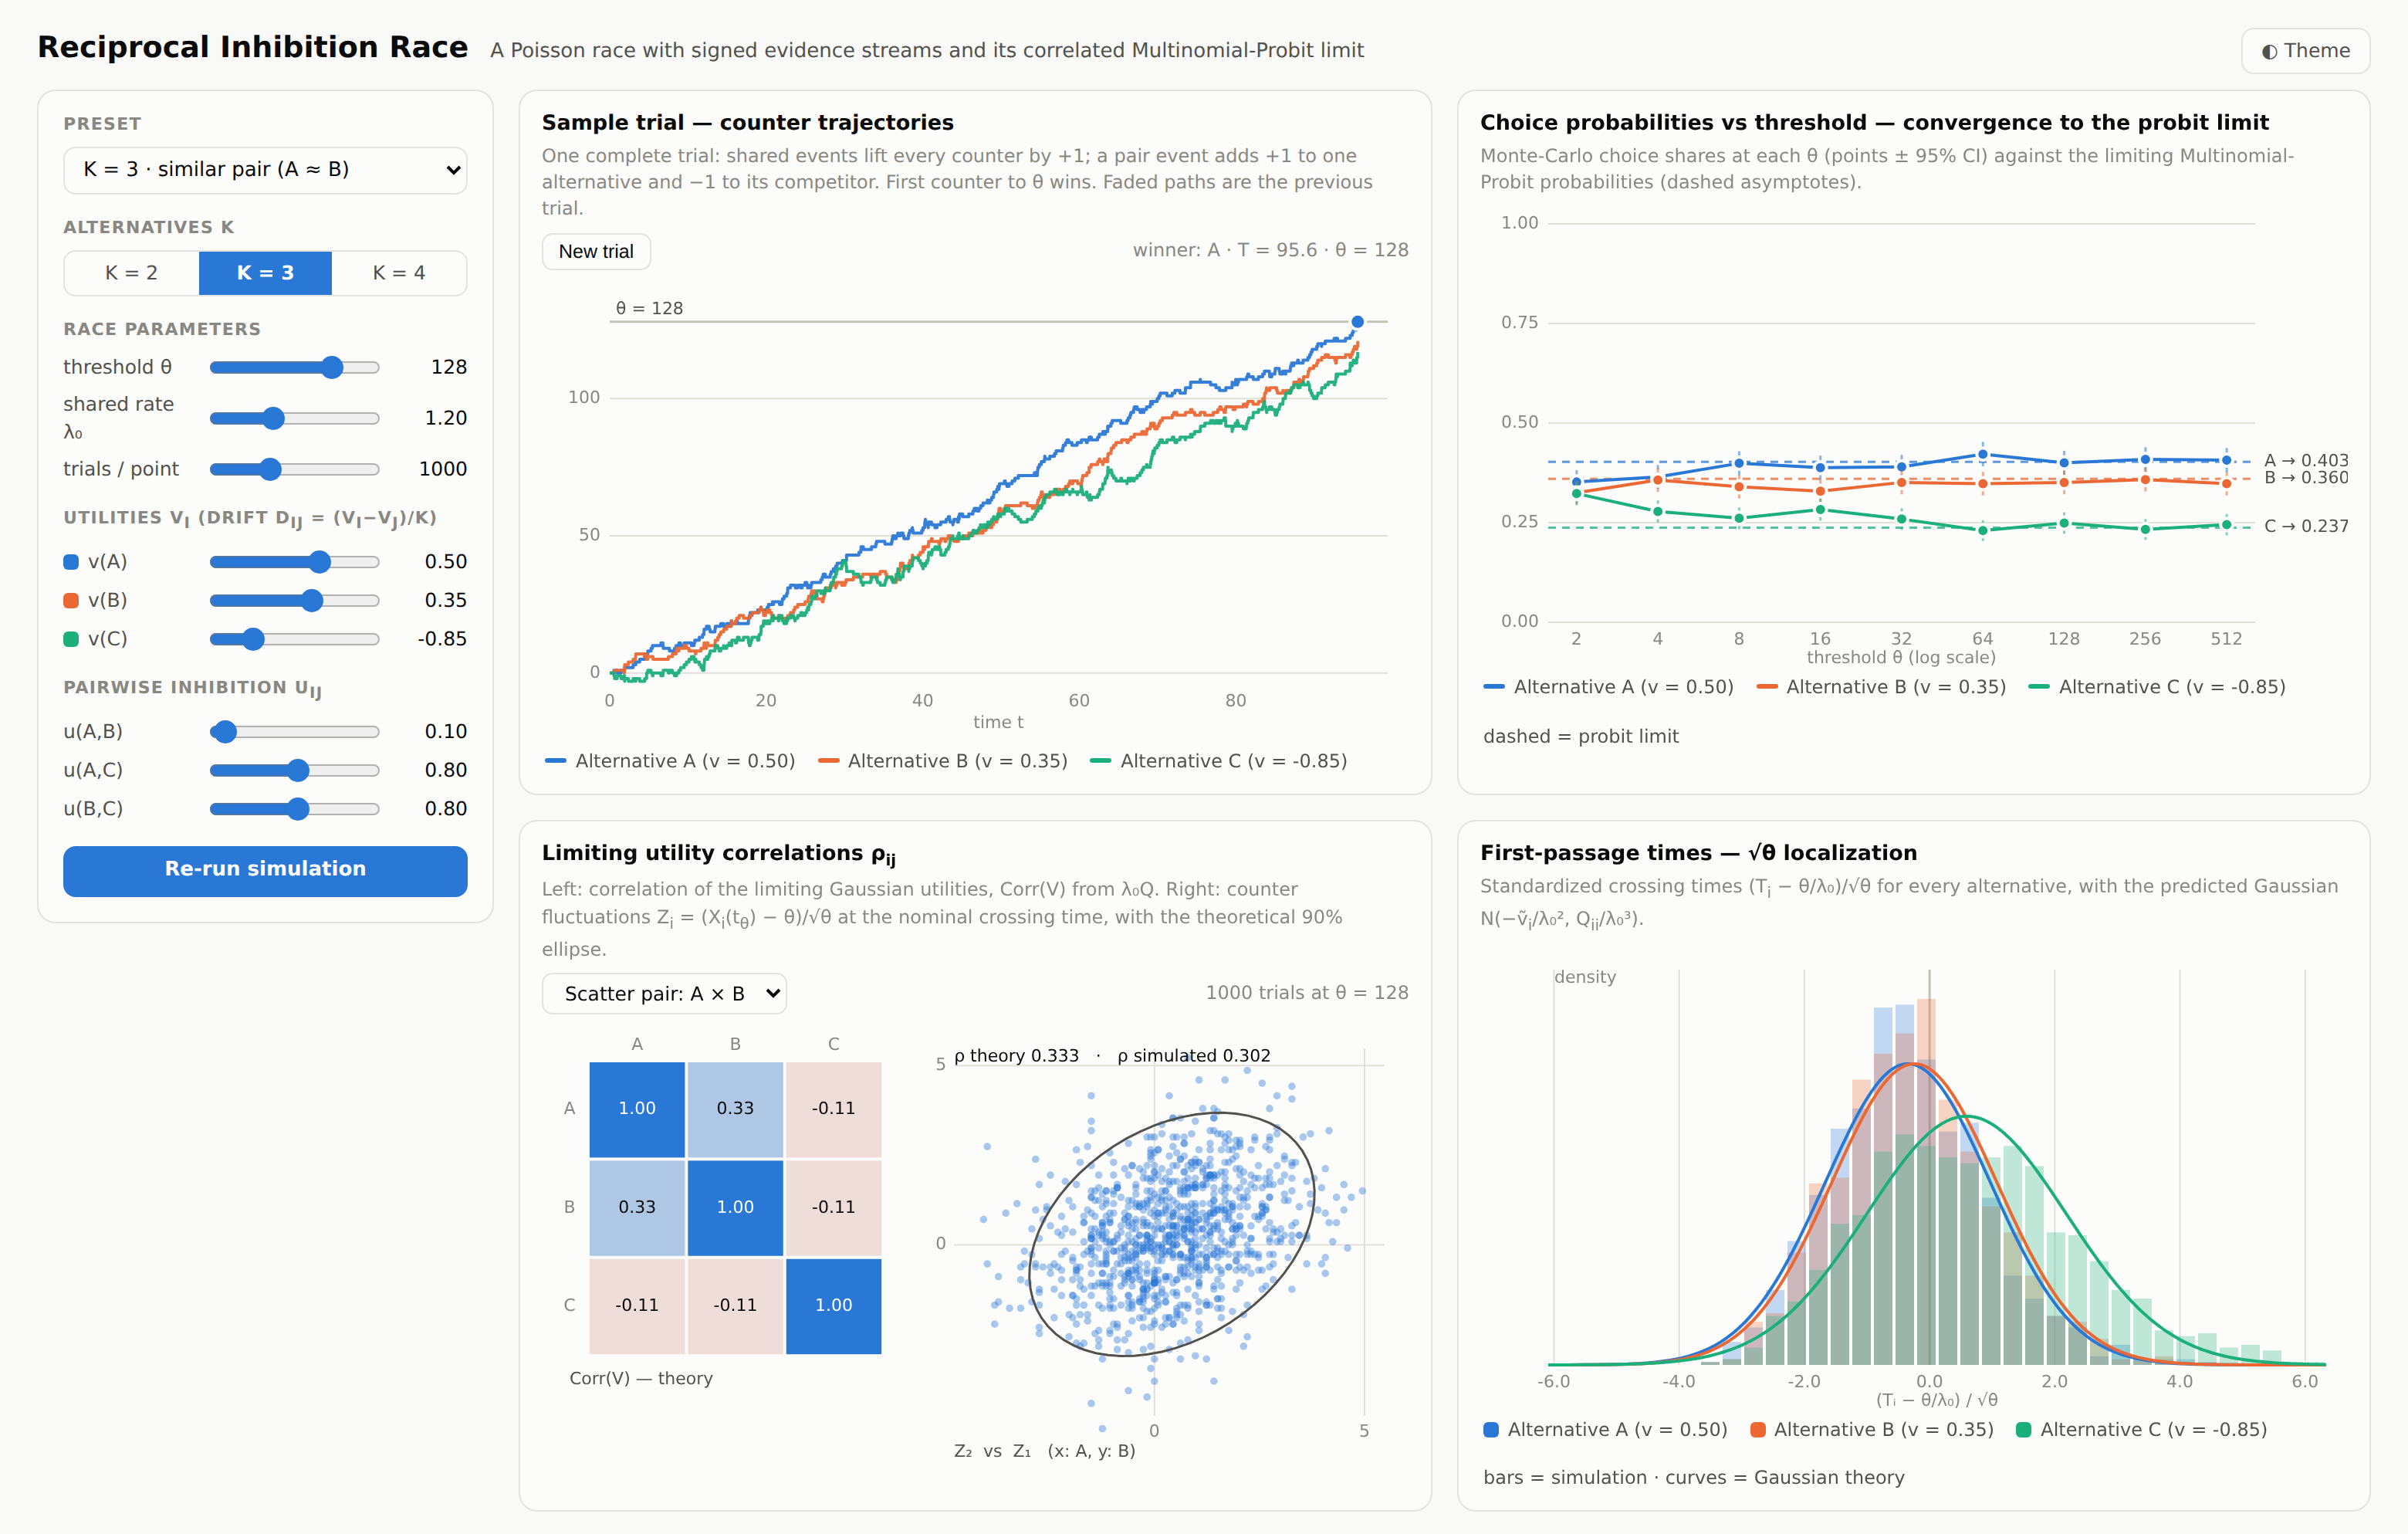
<figcaption>Figure 11: The interactive reciprocal-inhibition simulator, available at <a href="https://venpopov.com/logit-probit-poisson-rum/simulator.html">venpopov.com/logit-probit-poisson-rum/simulator.html</a>. Controls (left) set the threshold <span class="math inline">\(\theta\)</span>, the shared stream rate <span class="math inline">\(\lambda_0\)</span>, the utilities <span class="math inline">\(v_i\)</span>, and the pairwise inhibition weights <span class="math inline">\(u_{ij}\)</span>. Panels show the counter trajectories of a sample trial with the winning crossing marked (top left); Monte Carlo choice shares converging to the limiting Multinomial Probit probabilities as <span class="math inline">\(\theta\)</span> grows (top right); the limiting utility correlation matrix and the counter fluctuations <span class="math inline">\(Z_i = (X_i(t_\theta) - \theta)/\sqrt{\theta}\)</span> at the nominal crossing time with the theoretical 90% ellipse (bottom left); and the standardized first-passage times against their predicted Gaussian densities (bottom right).</figcaption>
</figure>

# 9. Discussion

The present work develops a generative framework in which Multinomial Logit and Multinomial Probit arise as endpoint regimes of a single parametric family of stochastic accumulation models. By combining a Poisson count race with a variance standardization that separates noise scale from noise shape, this paper clarifies how extreme-value and Gaussian choice behavior emerge as members of the log-Gamma random utility family, indexed by the accumulation threshold $\theta$. As discussed in <a href="#sec-variance-normalization" class="quarto-xref">Section 3</a>, this bridge is distributional rather than dynamical: the variance standardization compares different accumulation systems at matched discriminability, rather than describing the behavior of a single system under threshold manipulation. The framework, moreover, does not stop at the independent case: shared evidence streams generate a structured class of positively correlated probit models, and signed evidence streams recover the full choice-relevant covariance structure of the correlated Multinomial Probit in the high-threshold limit. The goal is not to advocate replacing existing models, but to clarify their relationship: logit and probit represent different positions within a continuum of log-Gamma noise shapes, with the accumulation threshold governing the transition between them.

The multinomial simulations demonstrate that this unification is not merely a theoretical curiosity. Thresholded accumulation induces systematic, graded violations of IIA that converge toward the dependence structure characteristic of multinomial probit. This dependence emerges endogenously from the accumulation and stopping rule, rather than being imposed by construction. The parameter invariance results further connect the framework to recent empirical findings ([Robinson et al., 2023](#ref-robinsonHowPeopleBuild2023)), providing a process-level account of why Gaussian-based parameters exhibit greater stability across changes in set size.

## 9.1 Relation to existing models

From a mathematical standpoint, all components of the present framework are classical: exponential races yield Luce’s choice rule, Gamma waiting times arise from accumulated Poisson events, and asymptotic normality follows from the Central Limit Theorem. Indeed, as reviewed in the introduction, both halves of the bridge predate it, separately — the distributional interpolation in survival analysis ([Prentice, 1974](#ref-prenticeLogGammaModel1974)) and the binary choice-function continuum in paired comparisons ([Stern, 1990](#ref-sternContinuumPairedComparisons1990)). The contribution of the present work lies in assembling these elements into a single generative account of multinomial choice, identifying the variance standardization under which the limiting behavior remains non-degenerate, and drawing out its consequences: the independent multinomial probit endpoint, a shared-generator extension yielding a structured class of correlated probit models, the $\rho_{\max}$ bound within that construction, a signed-stream construction that attains every choice-relevant probit covariance in the high-threshold limit (Result 5) together with the finite-threshold bound it carries, and the parameter-invariance crossover.

The conjoint Poisson race models reviewed in the introduction ([Otter et al., 2008](#ref-otterIntegratedModelDiscrete2008); [Ruan et al., 2008](#ref-ruanDependentPoissonRace2008a)) are the closest precedents on the process side, and the relationship deserves precision. Those efforts aim at a different target: the race serves as a richer descriptive model to be fit to choice data, with the threshold as a free parameter, and the links to logit, probit, and IIA are noted along the way rather than pursued. Here the threshold is instead treated as an interpolation index, and the race is used to establish a theoretical relationship — that multinomial logit and independent multinomial probit are the two endpoints of one family under matched discriminability, with the interpolation characterized distributionally (log-Gamma noise), proved in the limit, and quantified by simulation. The same precision applies on the dependence side. The dependent Poisson race of Ruan et al. ([2008](#ref-ruanDependentPoissonRace2008a)) induces correlation exclusively through shared event streams, and any construction of that type is confined to non-negative covariances of the common-shock form. Result 5 resolves the representation question this leaves open: once signed evidence streams are admitted, the high-threshold race attains every choice-relevant covariance of the correlated Multinomial Probit. The restriction to positive dependence is thus a property of purely excitatory event generation, not of race mechanisms as such.

The log-Gamma family should also be distinguished from link-level bridges between logit and probit. It has long been known that the logistic link is closely approximated by a Student-$t$ link with moderate degrees of freedom ([Mudholkar & George, 1978](#ref-mudholkarRemarkShapeLogistic1978)), and “robit” regression exploits this to interpolate between logistic and probit fits ([Liu, 2004](#ref-liuRobitRegressionSimple2004)); Prentice ([1976](#ref-prenticeGeneralizationProbitLogit1976a)) earlier proposed a four-parameter family of dose-response curves embedding the logit, probit, and extreme-value links as special cases. These families operate at the level of the link function: they are flexible curve-fitting devices, and their interpolation parameters carry no process interpretation. The family studied here is generative — every member corresponds to an explicit counting mechanism, its interpolation parameter is the amount of evidence required for commitment, and the same mechanism extends beyond the binary link to multinomial choice sets and correlated errors.

The present model should not be conflated with full sequential sampling models such as the Diffusion Decision Model ([Ratcliff, 1978](#ref-ratcliffTheoryMemoryRetrieval1978)) or Linear Ballistic Accumulator ([Brown & Heathcote, 2005](#ref-brownBallisticModelChoice2005)). Those models jointly account for response times and accuracy via continuous accumulation with explicit drift and boundary parameters. The Poisson count race is deliberately minimal: it uses accumulation as a generative device to induce a family of random utility models, without making claims about within-trial dynamics or response time distributions. The same reorientation applies to inhibition: reciprocal inhibitory coupling is a standard dynamical ingredient of models such as the leaky competing accumulator ([Usher & McClelland, 2001](#ref-usherTimeCoursePerceptual2001)), where it shapes within-trial trajectories, whereas <a href="#sec-inhibitory-race" class="quarto-xref">Section 8</a> repurposes it as a generative device whose role is to endow the limiting random utility model with a target covariance structure.

Between the logit and probit endpoints lies a continuum of log-Gamma random utility models. These intermediate regimes are not intended as new default specifications, but they underscore that logit and probit are special cases of a broader family. Deviations from logit or probit behavior may sometimes reflect differences in accumulation thresholds rather than fundamentally different noise sources.

## 9.2 Implications for empirical modeling

The present framework offers a theoretical account of why logit-based and probit-based models may differ in parameter invariance across task structures. Models with larger effective accumulation thresholds naturally exhibit Gaussian-like behavior, which may confer greater stability across changes in the number of alternatives. At the same time, the results caution against interpreting superior empirical performance of one model class as evidence for a particular noise distribution in isolation: differences between logit and probit may reflect differences in decision criteria or commitment thresholds rather than differences in representational noise per se.

The IIA analysis adds a complementary caution. Violations of IIA are commonly modeled as evidence of correlated utilities — similarity effects captured by nested logit or correlated probit specifications. Study 4 shows that graded, set-wide IIA violations arise with fully independent accumulators once the effective threshold exceeds one, because thin-tailed noise makes the odds between any two alternatives sensitive to the strength of the surrounding field. Observed IIA violations therefore admit two process interpretations — genuinely correlated evidence streams, whether excitatory or inhibitory (<a href="#sec-correlated-errors" class="quarto-xref">Section 7</a>, <a href="#sec-inhibitory-race" class="quarto-xref">Section 8</a>), or extensive independent evidence integration — and distinguishing them requires attention to the pattern of the violations, not merely their presence.

## 9.3 Limitations and extensions

The Poisson count race is intentionally simple and focuses exclusively on choice probabilities, abstracting away from response times and within-trial dynamics. Extensions such as time-varying rates or joint modeling of choice and response time are natural directions for future work.

Although the shared-feature extension of <a href="#sec-correlated-errors" class="quarto-xref">Section 7</a> demonstrates how correlated accumulators can generate a structured class of correlated Multinomial Probit models, common Poisson shocks generate only non-negative correlations, jointly realizable by a single collection of non-negative shared-generator rates. <a href="#sec-inhibitory-race" class="quarto-xref">Section 8</a> shows that admitting signed evidence streams removes this restriction: reciprocal inhibition with general loadings recovers, in the high-threshold limit, every choice-relevant probit covariance. The representation question is therefore resolved for the choice-relevant class, but at a price — the signed construction abandons non-negative counters and the exact Gamma waiting-time structure, so its finite-threshold members no longer belong to the log-Gamma random-utility family. Characterizing which covariances are attainable by constructions that retain the count-process representation at finite thresholds remains open.

The present analysis treats the accumulation threshold as fixed across trials and alternatives. Allowing threshold variability or adaptive stopping rules could further enrich the family of induced choice models and connect more directly to theories of decision caution and speed–accuracy trade-offs.

The model positions the Poisson count race as a parametric family indexed by $(\theta, \beta)$, but a formal identification analysis is beyond the present scope. In principle, $\theta$ and $\beta$ play distinct roles—shape versus scale of the noise distribution—and the shape of the psychometric function or the pattern of IIA violations could serve to identify $\theta$ from choice data. Existing results point in this direction: in the unstandardized thresholded race, Otter et al. ([2008](#ref-otterIntegratedModelDiscrete2008)) show that the structured departure from IIA identifies the threshold, and the rates up to a multiplicative constant, from repeated choices alone. Whether $\theta$ and $\beta$ remain jointly identifiable under the variance-standardized parameterization used here, and under what experimental designs, remains an open question for future investigation.

Finally, the framework naturally invites comparison with other random utility specifications. Exploring whether additional classical models arise as limiting regimes under alternative accumulation rules may provide further insight into the structure of discrete choice behavior.

## 9.4 Concluding remarks

By grounding discrete choice models in a common stochastic accumulation process, the Poisson count race reframes a long-standing modeling distinction. Logit and probit emerge not as competing assumptions about utility noise, but as members of a single parametric family — the log-Gamma random utility models — indexed by the accumulation threshold $\theta$. This unification is algebraic and distributional: it reveals that the two canonical specifications occupy endpoint positions within a continuous family of noise shapes, rather than representing fundamentally distinct generating mechanisms. At the same time, the unification does not imply that a single decision system can transition between regimes by adjusting its threshold alone, since the variance standardization that enables comparison across $\theta$ values entails different effective rate structures. The same asymptotic machinery also reaches beyond the independent case: shared evidence streams realize a structured, positively dependent subclass of correlated probit models, and signed evidence streams provide a generative foundation for the entire choice-relevant class. The framework thus clarifies the conceptual relationship between logit and probit and provides a principled basis for comparison, illustrating how process-level reasoning can illuminate the structure of static choice models.

# 10. References

Brown, S., & Heathcote, A. (2005). A Ballistic Model of Choice Response Time. *Psychological Review*, *112*(1), 117–128. <https://doi.org/10.1037/0033-295X.112.1.117>

Consul, P. C., & Jain, G. C. (1971). On the log-gamma distribution and its properties. *Statistische Hefte*, *12*(2), 100–106. <https://doi.org/10.1007/BF02922944>

Falmagne, J. C. (1978). A representation theorem for finite random scale systems. *Journal of Mathematical Psychology*, *18*(1), 52–72. <https://doi.org/10.1016/0022-2496(78)90048-2>

Hausman, J. A., & Wise, D. A. (1978). A Conditional Probit Model for Qualitative Choice: Discrete Decisions Recognizing Interdependence and Heterogeneous Preferences. *Econometrica*, *46*(2), 403–426. <https://doi.org/10.2307/1913909>

Kellen, D., Winiger, S., Dunn, J. C., & Singmann, H. (2021). Testing the foundations of signal detection theory in recognition memory. *Psychological Review*, *128*(6), 1022–1050. <https://doi.org/10.1037/rev0000288>

Lawless, J. F. (1980). Inference in the generalized gamma and log gamma distributions. *Technometrics*, *22*(3), 409–419. <https://doi.org/10.1080/00401706.1980.10486173>

Link, S. W., & Heath, R. A. (1975). A sequential theory of psychological discrimination. *Psychometrika*, *40*(1), 77–105. <https://doi.org/10.1007/BF02291481>

Liu, C. (2004). Robit regression: A simple robust alternative to logistic and probit regression. In A. Gelman & X.-L. Meng (Eds.), *Applied Bayesian modeling and causal inference from incomplete-data perspectives* (pp. 227–238). Wiley. <https://doi.org/10.1002/0470090456.ch21>

Luce, R. D. (1959). *Individual choice behavior* (pp. xii, 153). John Wiley.

Marley, A., & Colonius, H. (1992). The “horse race” random utility model for choice probabilities and reaction times, and its compering risks interpretation. *Journal of Mathematical Psychology*, *36*(1), 1–20. <https://doi.org/10.1016/0022-2496(92)90050-h>

McFadden, D. (1974). Conditional logit analysis of qualitative choice behavior. In *Frontiers in econometrics* (p. 105).

Mudholkar, G. S., & George, E. O. (1978). A remark on the shape of the logistic distribution. *Biometrika*, *65*(3), 667–668. <https://doi.org/10.1093/biomet/65.3.667>

Otter, T., Allenby, G. M., & Van Zandt, T. (2008). An integrated model of discrete choice and response time. *Journal of Marketing Research*, *45*(5), 593–607. <https://doi.org/10.1509/jmkr.45.5.593>

Pike, R. (1973). Response latency models for signal detection. *Psychological Review*, *80*(1), 53–68. <https://doi.org/10.1037/h0033871>

Pólya, G. (1920). Über den zentralen Grenzwertsatz der Wahrscheinlichkeitsrechnung und das Momentenproblem. *Mathematische Zeitschrift*, *8*(3-4), 171–181. <https://doi.org/10.1007/BF01206525>

Prentice, R. L. (1974). A log gamma model and its maximum likelihood estimation. *Biometrika*, *61*(3), 539–544. <https://doi.org/10.1093/biomet/61.3.539>

Prentice, R. L. (1976). A Generalization of the Probit and Logit Methods for Dose Response Curves. *Biometrics*, *32*(4), 761. <https://doi.org/10.2307/2529262>

Ratcliff, R. (1978). A theory of memory retrieval. *Psychological Review*, *85*(2), 59–108. <https://doi.org/10.1037/0033-295X.85.2.59>

Robinson, M. M., DeStefano, I. C., Vul, E., & Brady, T. F. (2023). How do people build up visual memory representations from sensory evidence? Revisiting two classic models of choice. *Journal of Mathematical Psychology*, *117*, 102805. <https://doi.org/10.1016/j.jmp.2023.102805>

Ruan, S., MacEachern, S. N., Otter, T., & Dean, A. M. (2008). The Dependent Poisson Race Model and Modeling Dependence in Conjoint Choice Experiments. *Psychometrika*, *73*(2), 261–288. <https://doi.org/10.1007/s11336-007-9035-y>

Smith, P. L., & Van Zandt, T. (2000). Time-dependent Poisson counter models of response latency in simple judgment. *British Journal of Mathematical and Statistical Psychology*, *53*(2), 293–315. <https://doi.org/10.1348/000711000159349>

Stacy, E. W. (1962). A generalization of the gamma distribution. *The Annals of Mathematical Statistics*, *33*(3), 1187–1192. <https://doi.org/10.1214/aoms/1177704481>

Stern, H. (1990). A continuum of paired comparisons models. *Biometrika*, *77*(2), 265–273. <https://doi.org/10.1093/biomet/77.2.265>

Stone, M. (1960). Models for choice-reaction time. *Psychometrika*, *25*(3), 251–260. <https://doi.org/10.1007/BF02289729>

Thurstone, L. L. (1927). A law of comparative judgment. *Psychological Review*, *34*(4), 273–286. <https://doi.org/10.1037/h0070288>

Townsend, J. T., & Ashby, F. G. (1983). *The stochastic modeling of elementary psychological processes*. Cambridge University Press.

Tuerlinckx, F., & De Boeck, P. (2004). *Stochastic models for personality trait judgments* \[Unpublished manuscript\].

Usher, M., & McClelland, J. L. (2001). The time course of perceptual choice: The leaky, competing accumulator model. *Psychological Review*, *108*(3), 550–592. <https://doi.org/10.1037/0033-295X.108.3.550>

Wixted, J. T. (2020). The forgotten history of signal detection theory. *Journal of Experimental Psychology: Learning, Memory, and Cognition*, *46*(2), 201–233. <https://doi.org/10.1037/xlm0000732>

Yellott, J. (1977). The relationship between Luce’s Choice Axiom, Thurstone’s Theory of Comparative Judgment, and the double exponential distribution. *Journal of Mathematical Psychology*, *15*(2), 109–144. <https://doi.org/10.1016/0022-2496(77)90026-8>